# Thresholded Static Graph Analysis of Sleep EEG Connectivity Networks

## Purpose

This notebook extends the stage-mean graph-theoretical analysis by examining
how static network measures behave after proportional thresholding of the
weighted phase-lag index (wPLI) connectivity graphs.

The input consists of subject-specific stage-mean EEG connectivity networks.
Each graph represents one participant, one sleep stage, and one frequency band.
It is created by averaging the valid 30-second epoch-level wPLI matrices within
that participant × stage × band combination.

The purpose of thresholding is not to replace the unthresholded analysis.
Instead, it provides a robustness analysis of graph topology under sparser,
stronger-edge network representations.

```text
Epoch-level wPLI graphs
        ↓
Average valid epochs within each subject × stage × band
        ↓
Stage-mean weighted wPLI graph
        ↓
Retain a fixed proportion of strongest edges
        ↓
Assess graph connectedness
        ↓
Calculate threshold-appropriate graph metrics
        ↓
Compare descriptive stage-related patterns across thresholds
```

This notebook focuses on whether observed network patterns are stable across
reasonable graph densities and whether the graph representation remains
connected enough for shortest-path-based integration metrics to be meaningful.

The analysis is descriptive and exploratory. The plots and metric tables
prepared here provide inputs for later subject-aware statistical testing; they
do not by themselves establish population-level sleep-stage effects.

---

## Input graphs

The notebook reads subject-level stage-mean HDF5 graph files. Each file
contains one weighted 83 × 83 wPLI adjacency matrix for every available sleep
stage and frequency band.

The analysis uses the following stages:

```text
Wake
N1
N2
N3
REM
```

The analysed frequency bands are:

| Band | Frequency range |
|---|---:|
| Delta | 0.5–4 Hz |
| Theta | 4–8 Hz |
| Alpha | 8–12 Hz |
| Sigma | 12–16 Hz |
| Beta | 16–30 Hz |

Each stage-mean graph is weighted, undirected, symmetric, and has a zero
diagonal. Before thresholding, all positive wPLI edges are available.

---

## Beta-band sensitivity specification

The beta-band input graphs used in this notebook apply the previously selected
peripheral-edge sensitivity correction:

```text
All 83 EEG nodes are retained.

Only beta-band edges with both endpoints in the peripheral-channel set
are set to zero before thresholding.

All other beta edges are retained.
```

This choice follows the earlier quality-control finding that peripheral channels
were over-represented among the strongest beta-band edges, with the effect
concentrated in peripheral–peripheral pairs. The concern is that these edges may
contain residual peripheral EMG or muscle-related contamination that changes
systematically across sleep stages.

The correction is intentionally narrow:

```text
Total possible edges:                 3,403
Both-peripheral beta edges excluded:    231
Fraction of possible edges removed:    6.8%
Edges still available:                 93.2%
```

This is a sensitivity-oriented graph construction choice. It does not imply
that all peripheral beta connectivity is artifactual. The selected beta-edge
mode is recorded in all output tables and should remain consistent throughout
comparisons.

---

## Proportional thresholding

A proportional threshold retains the same proportion of the strongest positive
edges in every graph.

For example:

```text
10% density:
    retain the strongest 10% of all possible undirected edges

20% density:
    retain the strongest 20% of all possible undirected edges

85% density:
    retain the strongest 85% of all possible undirected edges
```

This approach makes graph density comparable across subjects, stages, and
bands. It avoids allowing a graph with generally higher raw wPLI values to have
more retained edges simply because of its absolute weight scale.

The thresholding procedure:

1. Uses only unique upper-triangle edges.
2. Ranks positive wPLI values from strongest to weakest.
3. Retains the requested number of strongest edges.
4. Restores symmetry in the thresholded adjacency matrix.
5. Keeps the diagonal equal to zero.
6. Preserves excluded beta peripheral–peripheral edges at zero.

Because thresholding can disconnect a graph, graph connectedness is evaluated
explicitly before path-based metrics are calculated.

---

## Threshold families

Two threshold families are used because they answer different questions.

### Sparse-network sensitivity analysis

Sparse thresholds:

```text
10% density
20% density
30% density
```

At low densities, the retained graph contains only the strongest connections.
These sparse networks are useful for examining local clustering and community
structure among dominant edges.

However, low-density graphs may be disconnected. Therefore, sparse-network
results are used only for descriptive measures that remain interpretable in a
disconnected graph:

- Weighted clustering coefficient.
- Louvain modularity.
- Number of Louvain communities.
- Connected-component quality-control measures.

Shortest-path metrics are not calculated or interpreted for sparse graphs that
are disconnected.

### Connected-network robustness analysis

Connected thresholds:

```text
85% density
90% density
```

These thresholds are used for the primary integration robustness analysis.

Across the currently processed subject × stage × band graphs, the 85% and 90%
thresholds preserve full connectivity:

```text
Number of graphs: 700
Nodes per graph: 83

At 85% density:
    all graphs are fully connected

At 90% density:
    all graphs are fully connected
```

Because all nodes remain in a single connected component, shortest-path-based
metrics can be calculated meaningfully at these thresholds.

The connected-threshold analysis includes:

- Weighted global efficiency.
- Weighted characteristic path length.
- Weighted clustering coefficient.
- Louvain modularity.
- Number of Louvain communities.
- Graph connectedness quality-control fields.

---

## Graph metrics

For every thresholded graph, the notebook records graph size and connectedness:

| Field | Meaning |
|---|---|
| `n_nodes` | Number of graph nodes; expected to remain 83 |
| `n_edges` | Number of retained weighted edges |
| `edge_density` | Observed proportion of possible edges retained |
| `n_connected_components` | Number of disconnected components |
| `largest_component_size` | Number of nodes in the largest component |
| `fully_connected` | Whether all 83 nodes belong to one component |

The following topological metrics are calculated:

| Metric | Main interpretation |
|---|---|
| `mean_weighted_clustering` | Local segregation: whether a node's strongly connected neighbours also connect strongly to one another |
| `modularity_louvain` | Community-like organization: the extent to which the weighted graph separates into internally stronger communities |
| `n_louvain_communities` | Number of communities identified by weighted Louvain partitioning |
| `weighted_global_efficiency` | Global integration: how efficiently information can travel through short weighted paths |
| `weighted_characteristic_path_length` | Average shortest weighted path length; lower values indicate shorter routes between nodes |

For path-based metrics, connection strength is converted to distance:

```text
edge distance = 1 / wPLI
```

A stronger wPLI connection therefore corresponds to a shorter graph distance.

Louvain community detection uses a fixed random seed to make the partitioning
reproducible across reruns.

---

## Graph connectedness and interpretation

Connectivity is an essential quality-control condition for shortest-path
analysis.

```text
Connected graph:
    Every node can be reached from every other node.

Disconnected graph:
    At least one pair of nodes has no path connecting them.
```

Global efficiency and characteristic path length are calculated only in the
connected-threshold analysis, where all graphs have been verified to be fully
connected.

For sparse thresholds, disconnectedness is expected and is reported rather than
ignored. Sparse clustering and modularity can still be inspected
descriptively, but sparse results should not be interpreted as directly
equivalent to connected-network integration results.

---

## Outputs

The notebook produces separate metric tables for the sparse and connected
threshold families.

```text
Sparse threshold output:
    threshold_metrics_sparse_10_20_30_exclude_both_peripheral_beta.csv

Connected threshold output:
    threshold_metrics_connected_85_90_exclude_both_peripheral_beta.csv
```

Each row represents one:

```text
subject × frequency band × sleep stage × threshold density
```

Each row includes:

- Subject identifier.
- Frequency band.
- Sleep stage.
- Beta-edge mode.
- Number of epochs averaged to construct the stage-mean graph.
- Requested and observed edge density.
- Graph connectedness information.
- Thresholded graph metrics.

These tables are the main numerical outputs and should be used in later
subject-aware statistical analysis.

---

## Current visualizations

The notebook creates participant-level plots for the connected-threshold
analysis.

For each metric:

- Rows correspond to threshold density: 85% and 90%.
- Columns correspond to frequency band.
- The x-axis corresponds to sleep stage.
- Each grey line connects values from the same participant across stages.
- Boxplots summarize the distribution across participants.
- Individual points show participant-level values.

The primary connected-threshold visualizations display:

```text
Weighted global efficiency
Weighted characteristic path length
Weighted clustering coefficient
Louvain modularity
```

### Purpose of the plots

These visualizations are used to:

- Inspect within-participant changes across sleep stages.
- Show between-participant heterogeneity.
- Check whether descriptive patterns are similar at 85% and 90% density.
- Identify possible outlier values, missing-stage coverage, or unexpected
  numerical behaviour.
- Generate clearly defined hypotheses for later formal statistics.

### Important limitation

The plots are descriptive. They do not account for multiple comparisons,
stage-epoch imbalance, repeated measures, or uncertainty estimates from a
formal statistical model.

A visually stable pattern across 85% and 90% density supports robustness to
this particular threshold choice. It does not, by itself, establish a
population-level effect.

---

## Descriptive observations

The current connected-threshold plots suggest that stage-related patterns are
qualitatively similar at 85% and 90% density. This supports the conclusion that
the descriptive integration patterns are not driven by a single arbitrary
connected-threshold choice.

The main descriptive observations to be tested formally are:

- Sigma-band networks appear relatively more integrated during N2 and N3 and
  less integrated during REM.
- Delta-band integration appears relatively higher during Wake and N2 and lower
  during N1 and REM.
- Alpha-band integration may be reduced during REM, with substantial
  participant-to-participant variability.
- Theta-band integration appears comparatively stable across sleep stages.
- Beta-band integration appears to decrease toward N2/N3 and partly recover in
  REM, but individual variation is substantial.

These statements are preliminary descriptive patterns, not statistical
conclusions. They should be revisited using subject-aware statistical models
and appropriate correction for the number of tests.

Clustering and modularity are included as supplementary topology measures:

- Clustering describes local weighted neighbourhood structure.
- Modularity describes community-like weighted organization.
- Both measures can depend on graph density and methodological choices.
- Their role here is to complement, rather than replace, the primary
  connected-network integration analysis.

---

## Interpretation principles

- Treat each subject × stage × band graph as one repeated-measures observation,
  not as an independent sample.
- Do not pool all stage-mean graphs across participants without preserving the
  within-subject design.
- Do not compare or combine results from different beta-edge modes.
- Do not calculate or interpret characteristic path length for disconnected
  sparse graphs.
- Interpret sparse-threshold clustering and modularity as robustness-oriented,
  descriptive topology measures.
- Interpret agreement between 85% and 90% results as threshold robustness, not
  as complete robustness to every possible graph-construction choice.
- Consider the number of contributing epochs per stage graph during later
  sensitivity analysis.
- Treat current visualizations as exploratory evidence to guide formal
  statistical testing.

---

## Scope and next step

This notebook provides a threshold-aware extension of the stage-mean static
network analysis. It produces validated metric tables for sparse and connected
network representations and documents the graph-connectedness conditions under
which each metric is interpreted.

The next step is to perform subject-aware statistical analysis of the selected
primary metrics, beginning with connected-threshold integration measures:

```text
weighted global efficiency
weighted characteristic path length
```

Supplementary analyses can assess the stability of clustering and modularity
patterns across the connected and sparse threshold families.

In [ ]:
# ------------------------------------------------------------------
# THRESHOLDED STAGE-MEAN GRAPH METRICS
# Primary beta version: both-peripheral beta edges excluded
# Densities: 10%, 20%, 30%
# ------------------------------------------------------------------

from pathlib import Path
import time

import h5py
import numpy as np
import pandas as pd
import networkx as nx


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
STAGE_MEAN_DIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral"
)

THRESHOLD_OUTPUT_DIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral"
)
THRESHOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_DENSITIES = [0.10, 0.20, 0.30]

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]

LOUVAIN_SEED = 42

# Use None for the complete run.
# Set to 3 first if you want a short speed test.
MAX_SUBJECTS = None


# ------------------------------------------------------------------
# Find stage-mean HDF5 files
# ------------------------------------------------------------------
all_stage_mean_paths = sorted(
    STAGE_MEAN_DIR.glob("*_stage_means.h5")
)

if not all_stage_mean_paths:
    raise FileNotFoundError(
        f"No '*_stage_means.h5' files found in:\n"
        f"{STAGE_MEAN_DIR.resolve()}"
    )

if MAX_SUBJECTS is None:
    stage_mean_paths = all_stage_mean_paths
else:
    stage_mean_paths = all_stage_mean_paths[:MAX_SUBJECTS]

print(f"Available subject files: {len(all_stage_mean_paths)}")
print(f"Subject files to process: {len(stage_mean_paths)}")
print(
    "Threshold densities:",
    [f"{density:.0%}" for density in THRESHOLD_DENSITIES],
)


# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def decode_value(x):
    """Decode HDF5 byte strings when needed."""
    return x.decode() if isinstance(x, bytes) else str(x)


def prepare_adjacency(A):
    """
    Symmetrize a weighted adjacency matrix and enforce zero diagonal.
    """
    A = np.asarray(A, dtype=float).copy()
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    if np.any(A < 0):
        raise ValueError("The adjacency matrix contains negative weights.")

    return A


def threshold_proportional(A, density):
    """
    Retain exactly the strongest specified proportion of all possible
    undirected edges, keeping their original wPLI weights.

    Example:
    density = 0.10 retains the strongest 10% of 3403 possible edges.
    """
    if not 0 < density <= 1:
        raise ValueError("density must lie in the interval (0, 1].")

    A = prepare_adjacency(A)

    n_nodes = A.shape[0]
    upper_i, upper_j = np.triu_indices(n_nodes, k=1)
    upper_weights = A[upper_i, upper_j]

    n_possible_edges = len(upper_weights)
    n_keep = int(np.ceil(density * n_possible_edges))

    strongest_indices = np.argsort(
        upper_weights
    )[-n_keep:]

    kept_weights = upper_weights[strongest_indices]

    if np.any(kept_weights <= 0):
        raise ValueError(
            "The requested density includes zero-weight edges. "
            "Use a lower density or inspect the graph."
        )

    A_thresholded = np.zeros_like(A)

    kept_i = upper_i[strongest_indices]
    kept_j = upper_j[strongest_indices]

    A_thresholded[kept_i, kept_j] = kept_weights
    A_thresholded[kept_j, kept_i] = kept_weights

    return A_thresholded


def make_weighted_graph(A):
    """
    Create an undirected weighted graph.

    weight   = retained wPLI strength
    distance = 1 / wPLI, for shortest-path calculations
    """
    G = nx.from_numpy_array(A)

    for _, _, data in G.edges(data=True):
        weight = data["weight"]

        if weight <= 0:
            raise ValueError("A retained edge has non-positive weight.")

        data["distance"] = 1.0 / weight

    return G


def weighted_path_metrics(G):
    """
    Compute weighted global efficiency and characteristic path length
    using one shared all-pairs shortest-path calculation.

    Disconnected pairs contribute zero efficiency.
    Characteristic path length uses finite connected-pair distances.
    """
    nodes = list(G.nodes())

    if len(nodes) < 2:
        return np.nan, np.nan

    shortest_paths = dict(
        nx.all_pairs_dijkstra_path_length(G, weight="distance")
    )

    efficiencies = []
    finite_distances = []

    for i, source in enumerate(nodes):
        for target in nodes[i + 1:]:

            distance = shortest_paths[source].get(target, np.inf)

            if np.isfinite(distance) and distance > 0:
                efficiencies.append(1.0 / distance)
                finite_distances.append(distance)
            else:
                efficiencies.append(0.0)

    global_efficiency = float(np.mean(efficiencies))

    characteristic_path_length = (
        float(np.mean(finite_distances))
        if finite_distances
        else np.nan
    )

    return global_efficiency, characteristic_path_length


def compute_thresholded_metrics(A, density, seed=42):
    """
    Threshold one stage-mean graph and calculate selected weighted metrics.
    """
    A_thresholded = threshold_proportional(A, density=density)
    G = make_weighted_graph(A_thresholded)

    upper_triangle = A_thresholded[
        np.triu_indices_from(A_thresholded, k=1)
    ]

    retained_weights = upper_triangle[upper_triangle > 0]

    global_efficiency, characteristic_path_length = (
        weighted_path_metrics(G)
    )

    components = list(nx.connected_components(G))
    largest_component = max(components, key=len)

    try:
        communities = nx.community.louvain_communities(
            G,
            weight="weight",
            seed=seed,
        )

        modularity = nx.community.modularity(
            G,
            communities,
            weight="weight",
        )

        n_communities = len(communities)

    except Exception as error:
        print(f"Warning: Louvain failed: {error}")
        modularity = np.nan
        n_communities = np.nan

    return {
        # Threshold metadata / QC
        "threshold_density_target": density,
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "edge_density_actual": nx.density(G),
        "sparsity_actual": 1.0 - nx.density(G),
        "n_connected_components": len(components),
        "largest_component_size": len(largest_component),

        # Connectivity strength
        "mean_retained_wpli": float(np.mean(retained_weights)),
        "minimum_retained_wpli": float(np.min(retained_weights)),

        # Topology
        "mean_weighted_clustering": float(
            nx.average_clustering(G, weight="weight")
        ),
        "weighted_global_efficiency": global_efficiency,
        "weighted_characteristic_path_length":
            characteristic_path_length,
        "modularity_louvain": modularity,
        "n_louvain_communities": n_communities,
    }



Available subject files: 28
Subject files to process: 28
Threshold densities: ['10%', '20%', '30%']


In [ ]:
# ------------------------------------------------------------------
# Calculate thresholded metrics
# ------------------------------------------------------------------
rows = []

start_time = time.perf_counter()
graphs_completed = 0

for subject_number, h5_path in enumerate(
    stage_mean_paths,
    start=1,
):

    subject_start_time = time.perf_counter()

    with h5py.File(h5_path, "r") as f:

        subject_id = decode_value(f.attrs["subject_id"])
        beta_edge_mode = decode_value(f.attrs["beta_edge_mode"])

        bands_in_file = [
            decode_value(x)
            for x in f.attrs["bands"]
        ]

        stages_in_file = [
            decode_value(x)
            for x in f.attrs["stages"]
        ]

        bands = [
            band for band in BAND_ORDER
            if band in bands_in_file
        ]

        stages = [
            stage for stage in STAGE_ORDER
            if stage in stages_in_file
        ]

        for density in THRESHOLD_DENSITIES:
            for band in bands:
                for stage in stages:

                    if stage not in f[band]:
                        continue

                    A = f[band][stage][:]

                    graph_metrics = compute_thresholded_metrics(
                        A,
                        density=density,
                        seed=LOUVAIN_SEED,
                    )

                    rows.append({
                        "subject_id": subject_id,
                        "band": band,
                        "stage": stage,
                        "beta_edge_mode": beta_edge_mode,
                        "n_epochs_averaged": int(
                            f[band][stage]
                            .attrs["n_epochs_averaged"]
                        ),
                        **graph_metrics,
                    })

                    graphs_completed += 1

    subject_elapsed = time.perf_counter() - subject_start_time

    print(
        f"[{subject_number}/{len(stage_mean_paths)}] "
        f"{subject_id}: {subject_elapsed:.1f} s "
        f"({graphs_completed} thresholded graphs total)"
    )


# ------------------------------------------------------------------
# Save results
# ------------------------------------------------------------------
threshold_metrics_excluded = pd.DataFrame(rows)

csv_path = (
    THRESHOLD_OUTPUT_DIR
    / "thresholded_static_metrics_10_20_30_percent_"
      "exclude_both_peripheral_beta.csv"
)

pickle_path = (
    THRESHOLD_OUTPUT_DIR
    / "thresholded_static_metrics_10_20_30_percent_"
      "exclude_both_peripheral_beta.pkl"
)

threshold_metrics_excluded.to_csv(csv_path, index=False)
threshold_metrics_excluded.to_pickle(pickle_path)

elapsed_minutes = (
    time.perf_counter() - start_time
) / 60

print("\n" + "=" * 70)
print("THRESHOLDED STATIC METRICS COMPLETE")
print("=" * 70)
print(f"Rows created: {len(threshold_metrics_excluded)}")
print(f"Elapsed time: {elapsed_minutes:.2f} minutes")
print(f"Saved CSV: {csv_path.resolve()}")
print(f"Saved pickle: {pickle_path.resolve()}")

display(threshold_metrics_excluded.head())

#28 subjects × 5 bands × 5 stages × 3 densities = 2,100 rows

[1/28] EPCTL01: 16.5 s (75 thresholded graphs total)
[2/28] EPCTL02: 15.5 s (150 thresholded graphs total)
[3/28] EPCTL03: 7.9 s (225 thresholded graphs total)
[4/28] EPCTL04: 7.9 s (300 thresholded graphs total)
[5/28] EPCTL05: 7.7 s (375 thresholded graphs total)
[6/28] EPCTL06: 7.3 s (450 thresholded graphs total)
[7/28] EPCTL07: 8.5 s (525 thresholded graphs total)
[8/28] EPCTL09: 7.9 s (600 thresholded graphs total)
[9/28] EPCTL10: 7.9 s (675 thresholded graphs total)
[10/28] EPCTL11: 7.9 s (750 thresholded graphs total)
[11/28] EPCTL12: 8.4 s (825 thresholded graphs total)
[12/28] EPCTL13: 8.0 s (900 thresholded graphs total)
[13/28] EPCTL14: 19.8 s (975 thresholded graphs total)
[14/28] EPCTL15: 26.0 s (1050 thresholded graphs total)
[15/28] EPCTL16: 23.9 s (1125 thresholded graphs total)
[16/28] EPCTL17: 23.8 s (1200 thresholded graphs total)
[17/28] EPCTL18: 25.9 s (1275 thresholded graphs total)
[18/28] EPCTL19: 20.2 s (1350 thresholded graphs total)
[19/28] EPCTL20: 7.6 s (1

,subject_id,band,stage,beta_edge_mode,n_epochs_averaged,threshold_density_target,n_nodes,n_edges,edge_density_actual,sparsity_actual,n_connected_components,largest_component_size,mean_retained_wpli,minimum_retained_wpli,mean_weighted_clustering,weighted_global_efficiency,weighted_characteristic_path_length,modularity_louvain,n_louvain_communities
0,EPCTL01,delta,Wake,exclude_both_peripheral,46,0.1,83,341,0.100206,0.899794,4,80,0.346722,0.325986,0.215663,0.155910,6.806917,0.309952,7
1,EPCTL01,delta,N1,exclude_both_peripheral,74,0.1,83,341,0.100206,0.899794,30,54,0.293259,0.275604,0.161225,0.073488,6.541361,0.166125,32
2,EPCTL01,delta,N2,exclude_both_peripheral,471,0.1,83,341,0.100206,0.899794,36,48,0.314939,0.297313,0.151774,0.065098,5.964005,0.121310,40
3,EPCTL01,delta,N3,exclude_both_peripheral,185,0.1,83,341,0.100206,0.899794,10,73,0.288226,0.264183,0.139608,0.110743,8.057255,0.372852,14
4,EPCTL01,delta,REM,exclude_both_peripheral,176,0.1,83,341,0.100206,0.899794,7,77,0.220303,0.204862,0.339028,0.088217,11.514192,0.363522,11


In [5]:
expected_rows = (
    threshold_metrics_excluded["subject_id"].nunique()
    * threshold_metrics_excluded["band"].nunique()
    * threshold_metrics_excluded["stage"].nunique()
    * threshold_metrics_excluded[
        "threshold_density_target"
    ].nunique()
)

print("Expected rows:", expected_rows)
print("Actual rows:", len(threshold_metrics_excluded))

display(
    threshold_metrics_excluded
    .groupby("threshold_density_target")
    .agg(
        n_rows=("subject_id", "size"),
        mean_edges=("n_edges", "mean"),
        unique_edge_counts=("n_edges", "nunique"),
        mean_density=("edge_density_actual", "mean"),
        mean_components=("n_connected_components", "mean"),
        min_largest_component=(
            "largest_component_size",
            "min",
        ),
    )
)

Expected rows: 2100
Actual rows: 2100


,n_rows,mean_edges,unique_edge_counts,mean_density,mean_components,min_largest_component
threshold_density_target,,,,,,
0.1,700,341.0,1,0.100206,18.438571,38
0.2,700,681.0,1,0.200118,6.985714,55
0.3,700,1021.0,1,0.300029,3.174286,66


In [7]:
# ------------------------------------------------------------------
# CONNECTIVITY SCAN FOR PROPORTIONAL THRESHOLDS
# ------------------------------------------------------------------

CONNECTIVITY_DENSITIES = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90,
]

connectivity_rows = []

for h5_path in stage_mean_paths:

    with h5py.File(h5_path, "r") as f:

        subject_id = decode_value(f.attrs["subject_id"])

        bands_in_file = [
            decode_value(x)
            for x in f.attrs["bands"]
        ]

        stages_in_file = [
            decode_value(x)
            for x in f.attrs["stages"]
        ]

        bands = [
            band for band in BAND_ORDER
            if band in bands_in_file
        ]

        stages = [
            stage for stage in STAGE_ORDER
            if stage in stages_in_file
        ]

        for density in CONNECTIVITY_DENSITIES:
            for band in bands:
                for stage in stages:

                    A = f[band][stage][:]

                    A_thresholded = threshold_proportional(
                        A,
                        density=density,
                    )

                    G = nx.from_numpy_array(A_thresholded)

                    components = list(
                        nx.connected_components(G)
                    )

                    largest_component = max(
                        components,
                        key=len,
                    )

                    connectivity_rows.append({
                        "subject_id": subject_id,
                        "band": band,
                        "stage": stage,
                        "density": density,
                        "n_connected_components": len(components),
                        "largest_component_size": len(
                            largest_component
                        ),
                        "fully_connected": (
                            len(components) == 1
                        ),
                    })

connectivity_scan_df = pd.DataFrame(connectivity_rows)

connectivity_summary = (
    connectivity_scan_df
    .groupby("density")
    .agg(
        n_graphs=("fully_connected", "size"),
        proportion_fully_connected=(
            "fully_connected",
            "mean",
        ),
        mean_components=(
            "n_connected_components",
            "mean",
        ),
        max_components=(
            "n_connected_components",
            "max",
        ),
        min_largest_component=(
            "largest_component_size",
            "min",
        ),
    )
)

display(connectivity_summary)

,n_graphs,proportion_fully_connected,mean_components,max_components,min_largest_component
density,,,,,
0.10,700,0.001429,18.438571,46,38
0.20,700,0.098571,6.985714,29,55
0.30,700,0.385714,3.174286,17,66
0.40,700,0.617143,1.892857,11,73
0.50,700,0.787143,1.387143,9,75
0.60,700,0.887143,1.175714,5,79
0.70,700,0.957143,1.060000,3,81
0.75,700,0.980000,1.024286,3,81
0.80,700,0.991429,1.010000,3,81


**Why I keep the both-peripheral-beta-edge-excluded graph as the primary analysis:**

**The peripheral-check script found a systematic beta-specific concern:**

- Peripheral channels were over-represented among the strongest beta edges.
- The reported enrichment was about 1.36× above the chance baseline.
- The effect was concentrated in edges where both endpoints were peripheral.
- This pattern is consistent with shared peripheral EMG/muscle contamination, which matters because muscle tone varies systematically across Wake, NREM, and REM.

**And it's a very narrow correction:**

Total possible edges:                 3,403 

Both-peripheral edges removed:          231

Fraction removed:                       6.8%

Edges retained:                         93.2%

In [13]:
from pathlib import Path
import time

import h5py
import networkx as nx
import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

# IMPORTANT:
# Use the SAME input directory used for your excluded-beta
# connectivity scan. Do not use the full-beta directory here.
STAGEMEANDIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral"
)

THRESHOLD_OUTPUT_DIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral"
)
THRESHOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SPARSE_DENSITIES = [0.10, 0.20, 0.30]
CONNECTED_DENSITIES = [0.85, 0.90]

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]
LOUVAIN_SEED = 42


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------

def decode_value(x):
    return x.decode() if isinstance(x, bytes) else str(x)


def proportional_threshold(A, density):
    """
    Retain exactly ceil(density * all_possible_undirected_edges)
    strongest positive edges. Excluded beta edges remain zero and
    can never be selected.
    """
    A = np.asarray(A, dtype=float).copy()
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    n_nodes = A.shape[0]
    iu, ju = np.triu_indices(n_nodes, k=1)

    weights = A[iu, ju]
    positive_idx = np.flatnonzero(weights > 0)

    n_possible_edges = len(weights)
    n_edges_to_keep = int(np.ceil(density * n_possible_edges))

    if n_edges_to_keep > len(positive_idx):
        raise ValueError(
            f"Density {density:.2f} requests {n_edges_to_keep} edges, "
            f"but this graph has only {len(positive_idx)} positive edges."
        )

    ranked_positive_idx = positive_idx[
        np.argsort(weights[positive_idx], kind="mergesort")[::-1]
    ]
    keep_idx = ranked_positive_idx[:n_edges_to_keep]

    A_thresholded = np.zeros_like(A)
    A_thresholded[iu[keep_idx], ju[keep_idx]] = weights[keep_idx]
    A_thresholded[ju[keep_idx], iu[keep_idx]] = weights[keep_idx]

    return A_thresholded


def weighted_graph_from_adjacency(A):
    """
    Creates a graph where:
    - weight = wPLI strength
    - distance = 1 / wPLI, used for shortest-path calculations
    """
    G = nx.from_numpy_array(A)

    for _, _, data in G.edges(data=True):
        weight = data["weight"]

        if weight <= 0:
            raise ValueError("A retained edge has non-positive weight.")

        data["distance"] = 1.0 / weight

    return G


def weighted_global_efficiency_and_path_length(G):
    """
    Computes weighted global efficiency and characteristic path length
    from all-pairs Dijkstra distances.

    This function should only be used after confirming that G is
    connected.
    """
    nodes = list(G.nodes())
    distances = dict(nx.all_pairs_dijkstra_path_length(G, weight="distance"))

    inverse_distances = []
    path_lengths = []

    for i, source in enumerate(nodes):
        for target in nodes[i + 1:]:
            d = distances[source][target]

            inverse_distances.append(1.0 / d)
            path_lengths.append(d)

    return (
        float(np.mean(inverse_distances)),
        float(np.mean(path_lengths)),
    )


def graph_qc(G):
    components = list(nx.connected_components(G))
    largest_component = max(components, key=len)

    return {
        "n_nodes": G.number_of_nodes(),
        "n_edges": G.number_of_edges(),
        "edge_density": nx.density(G),
        "n_connected_components": len(components),
        "largest_component_size": len(largest_component),
        "fully_connected": len(components) == 1,
    }


def clustering_and_modularity(G):
    weighted_clustering = float(
        nx.average_clustering(G, weight="weight")
    )

    communities = nx.community.louvain_communities(
        G,
        weight="weight",
        seed=LOUVAIN_SEED,
    )

    modularity = float(
        nx.community.modularity(
            G,
            communities,
            weight="weight",
        )
    )

    return {
        "mean_weighted_clustering": weighted_clustering,
        "modularity_louvain": modularity,
        "n_louvain_communities": len(communities),
    }


def metrics_at_density(A, density, analysis_set):
    A_thresholded = proportional_threshold(A, density)
    G = weighted_graph_from_adjacency(A_thresholded)

    result = {
        "requested_density": density,
        "analysis_set": analysis_set,
        **graph_qc(G),
        **clustering_and_modularity(G),
    }

    # Only calculate and interpret path metrics at 85% and 90%.
    if analysis_set == "connected":
        if not result["fully_connected"]:
            raise RuntimeError(
                f"Graph is disconnected at density {density:.2f}, "
                "so path-based metrics must not be calculated."
            )

        efficiency, path_length = (
            weighted_global_efficiency_and_path_length(G)
        )

        result["weighted_global_efficiency"] = efficiency
        result["weighted_characteristic_path_length"] = path_length

    else:
        result["weighted_global_efficiency"] = np.nan
        result["weighted_characteristic_path_length"] = np.nan

    return result


# ------------------------------------------------------------------
# Locate excluded-beta stage-mean graph files
# ------------------------------------------------------------------

stage_mean_paths = sorted(STAGEMEANDIR.glob("*stage_means.h5"))

if not stage_mean_paths:
    raise FileNotFoundError(
        f"No stage-mean HDF5 files found in:\n{STAGEMEANDIR.resolve()}"
    )

print(f"Found {len(stage_mean_paths)} excluded-beta stage-mean files.")


# ------------------------------------------------------------------
# Compute both threshold families
# ------------------------------------------------------------------

sparse_rows = []
connected_rows = []

start_time = time.perf_counter()
graphs_completed = 0

for subject_number, h5path in enumerate(stage_mean_paths, start=1):

    with h5py.File(h5path, "r") as f:
        subject_id = decode_value(f.attrs["subject_id"])
        beta_edge_mode = decode_value(f.attrs["beta_edge_mode"])

        if beta_edge_mode != "exclude_both_peripheral":
            raise ValueError(
                f"{h5path.name} has beta_edge_mode={beta_edge_mode!r}. "
                "This analysis must use excluded-beta graphs."
            )

        available_bands = [
            decode_value(x)
            for x in f.attrs["bands"]
        ]
        available_stages = [
            decode_value(x)
            for x in f.attrs["stages"]
        ]

        bands = [
            band for band in BAND_ORDER
            if band in available_bands
        ]
        stages = [
            stage for stage in STAGE_ORDER
            if stage in available_stages
        ]

        for band in bands:
            for stage in stages:

                if stage not in f[band]:
                    continue

                A = np.asarray(f[band][stage], dtype=float)
                n_epochs_averaged = int(
                    f[band][stage].attrs["n_epochs_averaged"]
                )

                metadata = {
                    "subjectid": subject_id,
                    "band": band,
                    "stage": stage,
                    "betaedgemode": beta_edge_mode,
                    "nepochsaveraged": n_epochs_averaged,
                }

                # Sparse-network robustness:
                # clustering and modularity only.
                for density in SPARSE_DENSITIES:
                    result = metrics_at_density(
                        A=A,
                        density=density,
                        analysis_set="sparse",
                    )
                    sparse_rows.append({**metadata, **result})

                # Connected-network robustness:
                # clustering, modularity, efficiency, and path length.
                for density in CONNECTED_DENSITIES:
                    result = metrics_at_density(
                        A=A,
                        density=density,
                        analysis_set="connected",
                    )
                    connected_rows.append({**metadata, **result})

                graphs_completed += 1

    print(
        f"{subject_number:02d}/{len(stage_mean_paths)} "
        f"{subject_id} complete "
        f"({graphs_completed} subject-band-stage graphs)"
    )


# ------------------------------------------------------------------
# Create and validate output tables
# ------------------------------------------------------------------

threshold_metrics_sparse = pd.DataFrame(sparse_rows)
threshold_metrics_connected = pd.DataFrame(connected_rows)

expected_sparse_rows = graphs_completed * len(SPARSE_DENSITIES)
expected_connected_rows = graphs_completed * len(CONNECTED_DENSITIES)

assert len(threshold_metrics_sparse) == expected_sparse_rows
assert len(threshold_metrics_connected) == expected_connected_rows

assert set(
    threshold_metrics_sparse["requested_density"].unique()
) == set(SPARSE_DENSITIES)

assert set(
    threshold_metrics_connected["requested_density"].unique()
) == set(CONNECTED_DENSITIES)

assert threshold_metrics_connected["fully_connected"].all(), (
    "At least one graph was disconnected at 85% or 90%. "
    "Do not interpret the path-based results until this is resolved."
)

assert (
    threshold_metrics_connected["n_connected_components"] == 1
).all()

assert (
    threshold_metrics_connected["largest_component_size"] == 83
).all()


# ------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------

sparse_output_path = THRESHOLD_OUTPUT_DIR / (
    "threshold_metrics_sparse_10_20_30_"
    "exclude_both_peripheral_beta.csv"
)

connected_output_path = THRESHOLD_OUTPUT_DIR / (
    "threshold_metrics_connected_85_90_"
    "exclude_both_peripheral_beta.csv"
)

threshold_metrics_sparse.to_csv(
    sparse_output_path,
    index=False,
)

threshold_metrics_connected.to_csv(
    connected_output_path,
    index=False,
)


# ------------------------------------------------------------------
# Report
# ------------------------------------------------------------------

elapsed_minutes = (time.perf_counter() - start_time) / 60

print("\n" + "=" * 70)
print("THRESHOLDED PRIMARY ANALYSIS COMPLETE")
print("=" * 70)
print(f"Subject-band-stage graphs processed: {graphs_completed}")
print(f"Sparse rows: {len(threshold_metrics_sparse)}")
print(f"Connected rows: {len(threshold_metrics_connected)}")
print(f"Elapsed time: {elapsed_minutes:.2f} minutes")

print("\nSparse-threshold QC:")
display(
    threshold_metrics_sparse
    .groupby("requested_density")
    .agg(
        n_graphs=("subjectid", "size"),
        proportion_fully_connected=("fully_connected", "mean"),
        mean_components=("n_connected_components", "mean"),
        max_components=("n_connected_components", "max"),
    )
    .reset_index()
)

print("\nConnected-threshold QC:")
display(
    threshold_metrics_connected
    .groupby("requested_density")
    .agg(
        n_graphs=("subjectid", "size"),
        proportion_fully_connected=("fully_connected", "mean"),
        mean_components=("n_connected_components", "mean"),
        min_largest_component=("largest_component_size", "min"),
    )
    .reset_index()
)

print("\nSparse metrics preview:")
display(threshold_metrics_sparse.head())

print("\nConnected metrics preview:")
display(threshold_metrics_connected.head())

Found 28 excluded-beta stage-mean files.
01/28 EPCTL01 complete (25 subject-band-stage graphs)
02/28 EPCTL02 complete (50 subject-band-stage graphs)
03/28 EPCTL03 complete (75 subject-band-stage graphs)
04/28 EPCTL04 complete (100 subject-band-stage graphs)
05/28 EPCTL05 complete (125 subject-band-stage graphs)
06/28 EPCTL06 complete (150 subject-band-stage graphs)
07/28 EPCTL07 complete (175 subject-band-stage graphs)
08/28 EPCTL09 complete (200 subject-band-stage graphs)
09/28 EPCTL10 complete (225 subject-band-stage graphs)
10/28 EPCTL11 complete (250 subject-band-stage graphs)
11/28 EPCTL12 complete (275 subject-band-stage graphs)
12/28 EPCTL13 complete (300 subject-band-stage graphs)
13/28 EPCTL14 complete (325 subject-band-stage graphs)
14/28 EPCTL15 complete (350 subject-band-stage graphs)
15/28 EPCTL16 complete (375 subject-band-stage graphs)
16/28 EPCTL17 complete (400 subject-band-stage graphs)
17/28 EPCTL18 complete (425 subject-band-stage graphs)
18/28 EPCTL19 complete (450

,requested_density,n_graphs,proportion_fully_connected,mean_components,max_components
0,0.1,700,0.001429,18.438571,46
1,0.2,700,0.098571,6.985714,29
2,0.3,700,0.385714,3.174286,17



Connected-threshold QC:


,requested_density,n_graphs,proportion_fully_connected,mean_components,min_largest_component
0,0.85,700,1.0,1.0,83
1,0.90,700,1.0,1.0,83



Sparse metrics preview:


,subjectid,band,stage,betaedgemode,nepochsaveraged,requested_density,analysis_set,n_nodes,n_edges,edge_density,n_connected_components,largest_component_size,fully_connected,mean_weighted_clustering,modularity_louvain,n_louvain_communities,weighted_global_efficiency,weighted_characteristic_path_length
0,EPCTL01,delta,Wake,exclude_both_peripheral,46,0.1,sparse,83,341,0.100206,4,80,False,0.215663,0.309952,7,NaN,NaN
1,EPCTL01,delta,Wake,exclude_both_peripheral,46,0.2,sparse,83,681,0.200118,1,83,True,0.309891,0.247188,4,NaN,NaN
2,EPCTL01,delta,Wake,exclude_both_peripheral,46,0.3,sparse,83,1021,0.300029,1,83,True,0.354801,0.208250,3,NaN,NaN
3,EPCTL01,delta,N1,exclude_both_peripheral,74,0.1,sparse,83,341,0.100206,30,54,False,0.161225,0.166125,32,NaN,NaN
4,EPCTL01,delta,N1,exclude_both_peripheral,74,0.2,sparse,83,681,0.200118,19,65,False,0.254221,0.095298,21,NaN,NaN



Connected metrics preview:


,subjectid,band,stage,betaedgemode,nepochsaveraged,requested_density,analysis_set,n_nodes,n_edges,edge_density,n_connected_components,largest_component_size,fully_connected,mean_weighted_clustering,modularity_louvain,n_louvain_communities,weighted_global_efficiency,weighted_characteristic_path_length
0,EPCTL01,delta,Wake,exclude_both_peripheral,46,0.85,connected,83,2893,0.850132,1,83,True,0.572779,0.045980,2,0.272630,3.845244
1,EPCTL01,delta,Wake,exclude_both_peripheral,46,0.90,connected,83,3063,0.900088,1,83,True,0.593584,0.038434,2,0.276342,3.754052
2,EPCTL01,delta,N1,exclude_both_peripheral,74,0.85,connected,83,2893,0.850132,1,83,True,0.562674,0.026690,3,0.216795,4.886744
3,EPCTL01,delta,N1,exclude_both_peripheral,74,0.90,connected,83,3063,0.900088,1,83,True,0.575923,0.017142,3,0.219614,4.767431
4,EPCTL01,delta,N2,exclude_both_peripheral,471,0.85,connected,83,2893,0.850132,1,83,True,0.581902,0.020536,3,0.237286,4.481462


Now:

Primary thresholded integration robustness:
85% and 90%
- Global efficiency
- Characteristic path length
- Optionally clustering and modularity

Sparse-threshold descriptive sensitivity:
10%, 20%, 30%
- Weighted clustering
- Modularity, explicitly accompanied by component QC
- Do not make strong claims from community count alone

Beta-edge mode plotted:
<StringArray>
['exclude_both_peripheral']
Length: 1, dtype: str

Graphs per density:


,requested_density,n_graphs
0,0.85,700
1,0.90,700


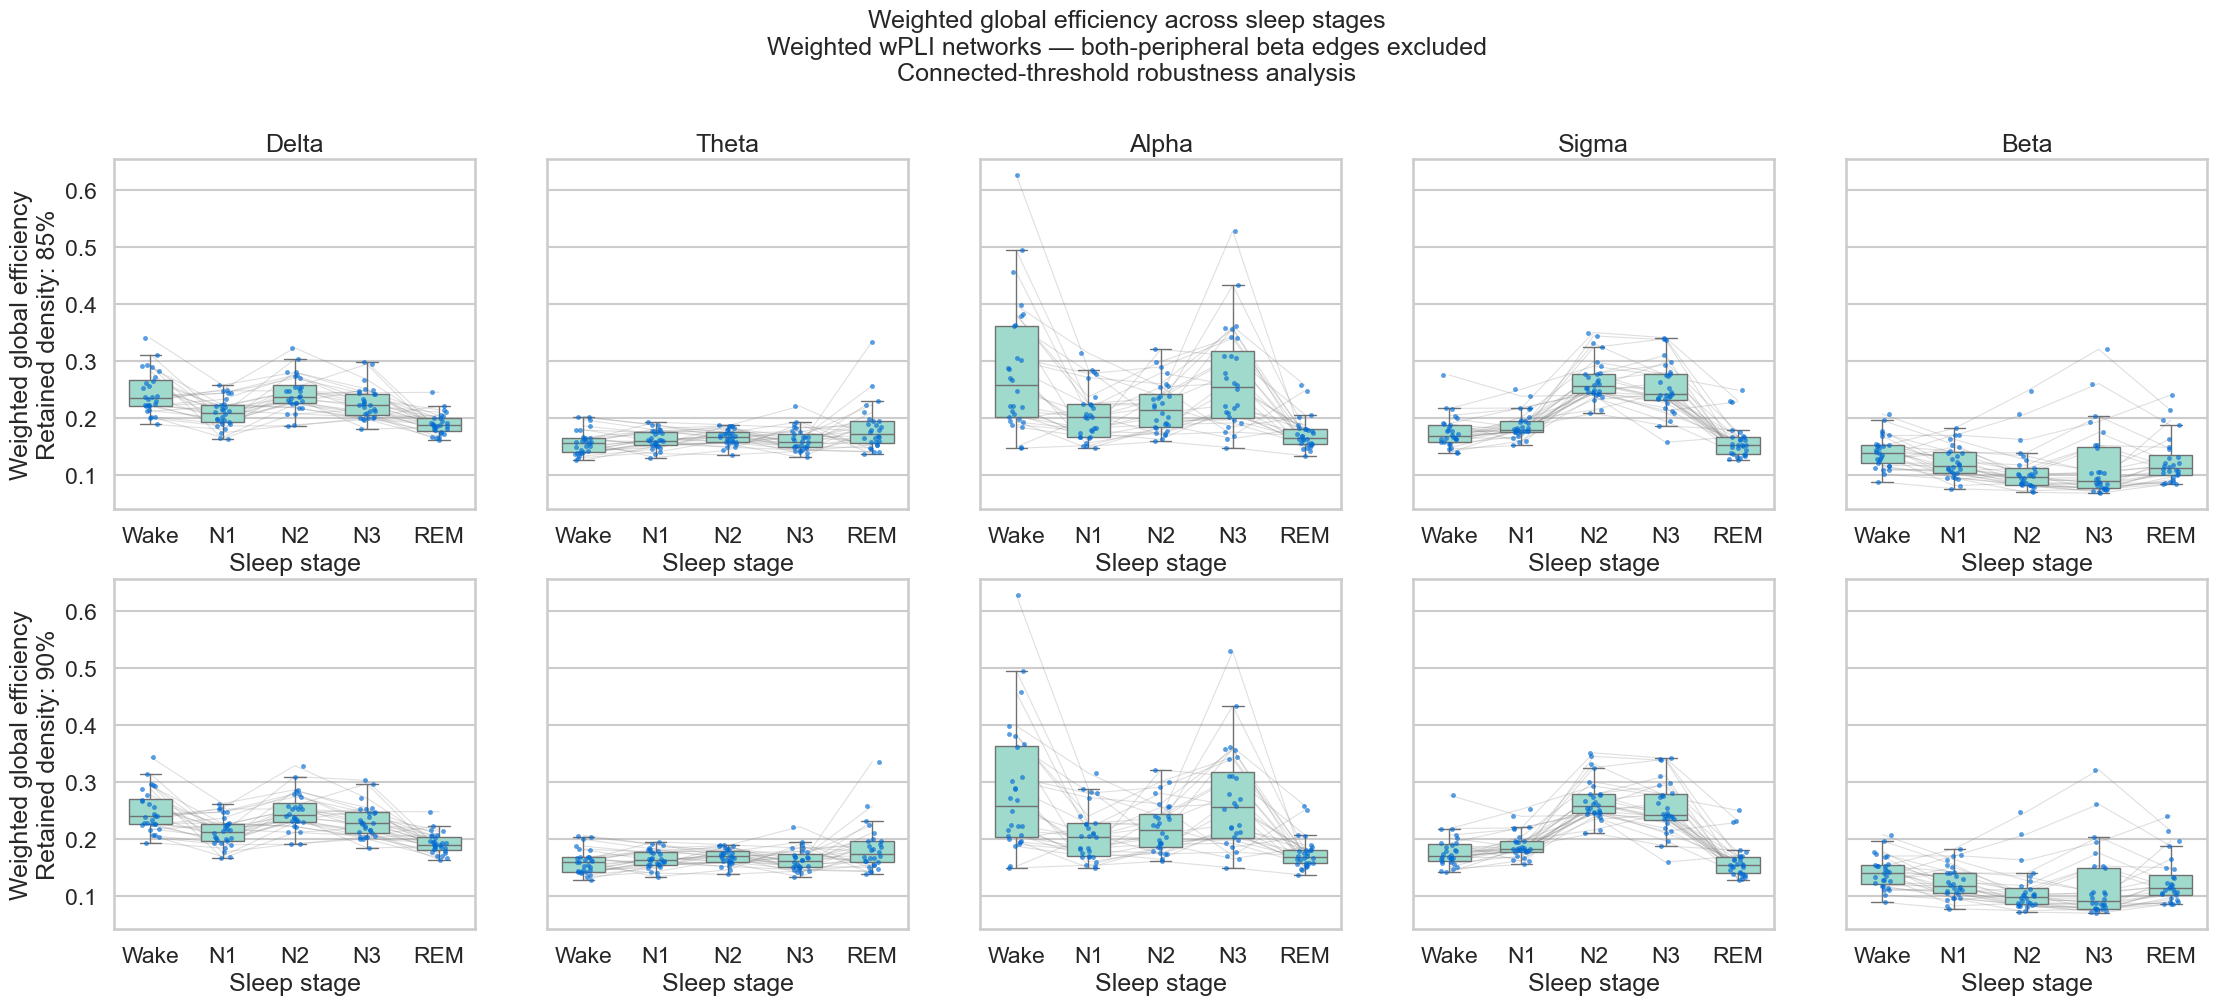

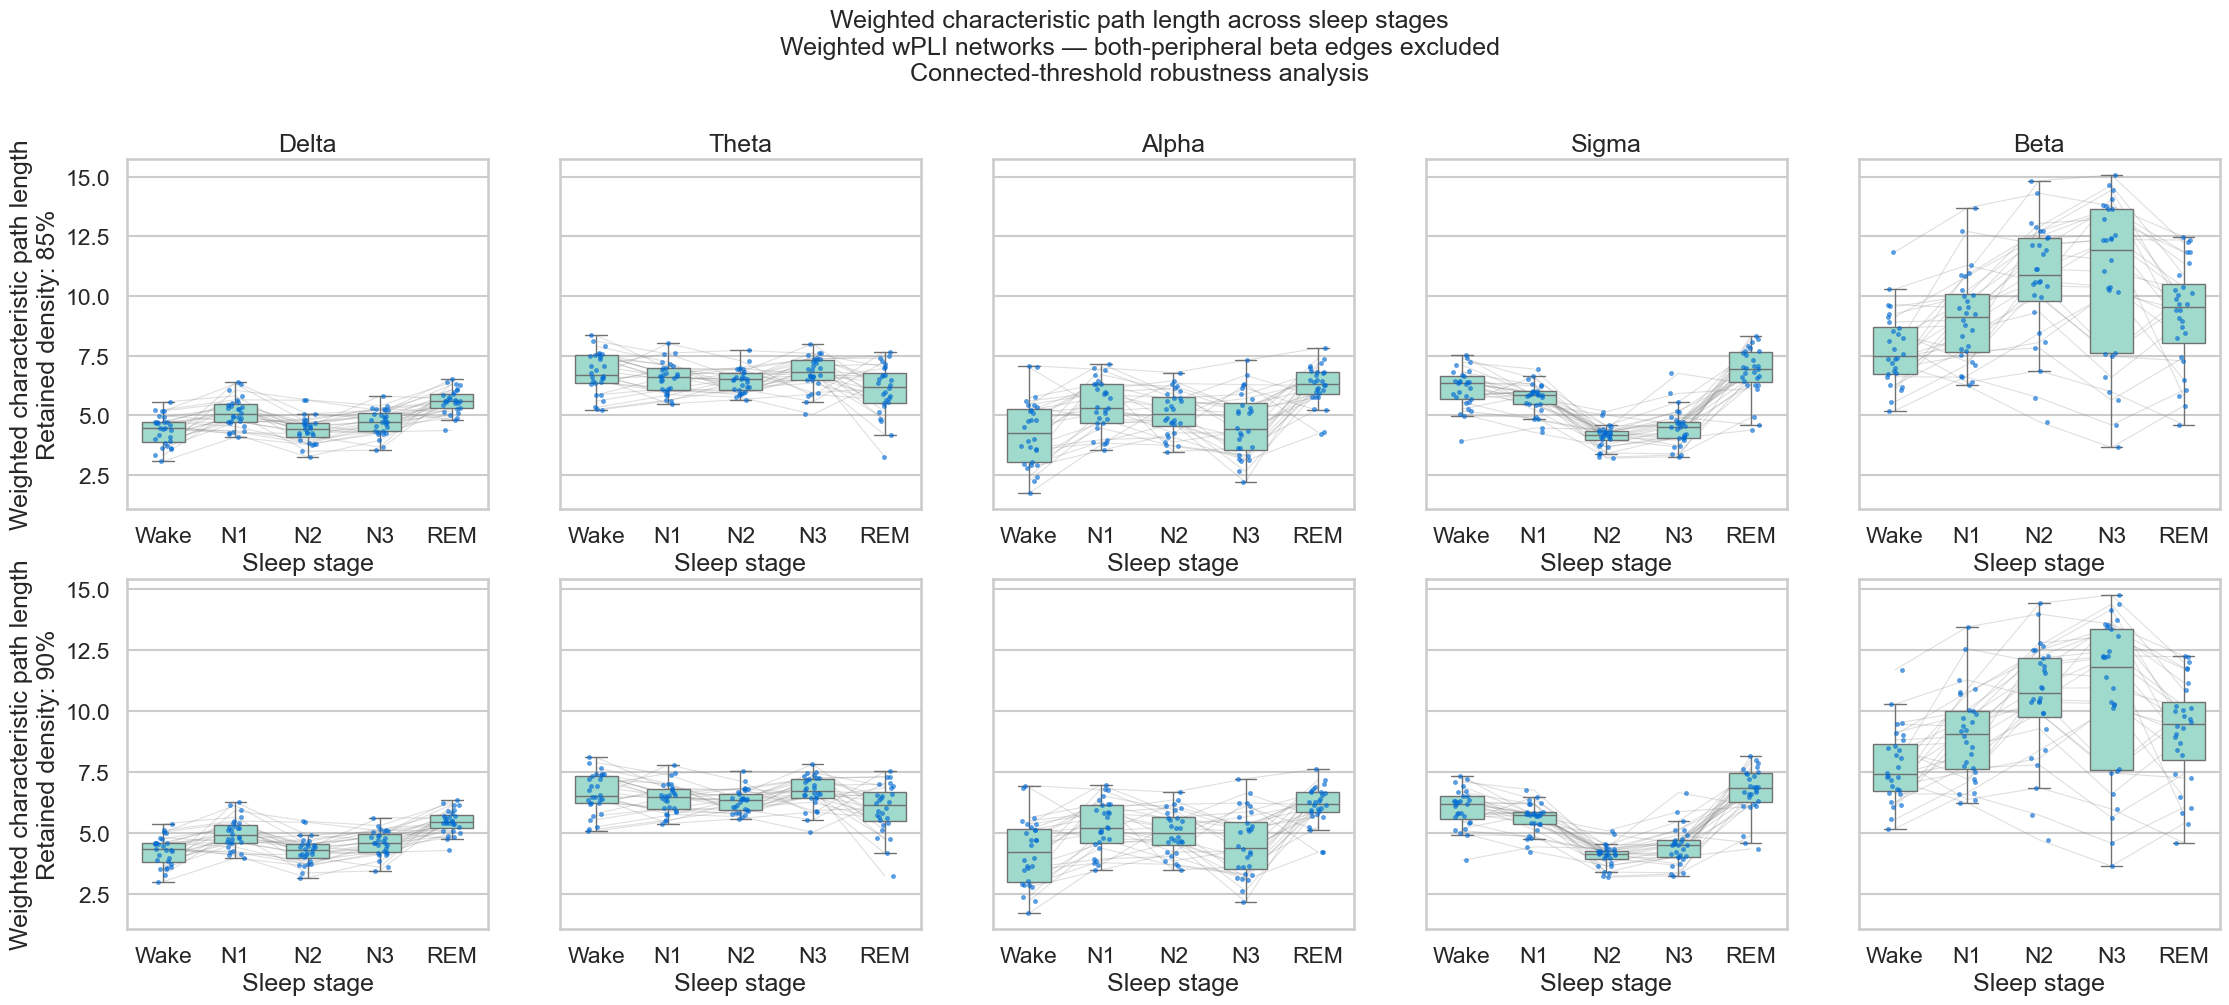

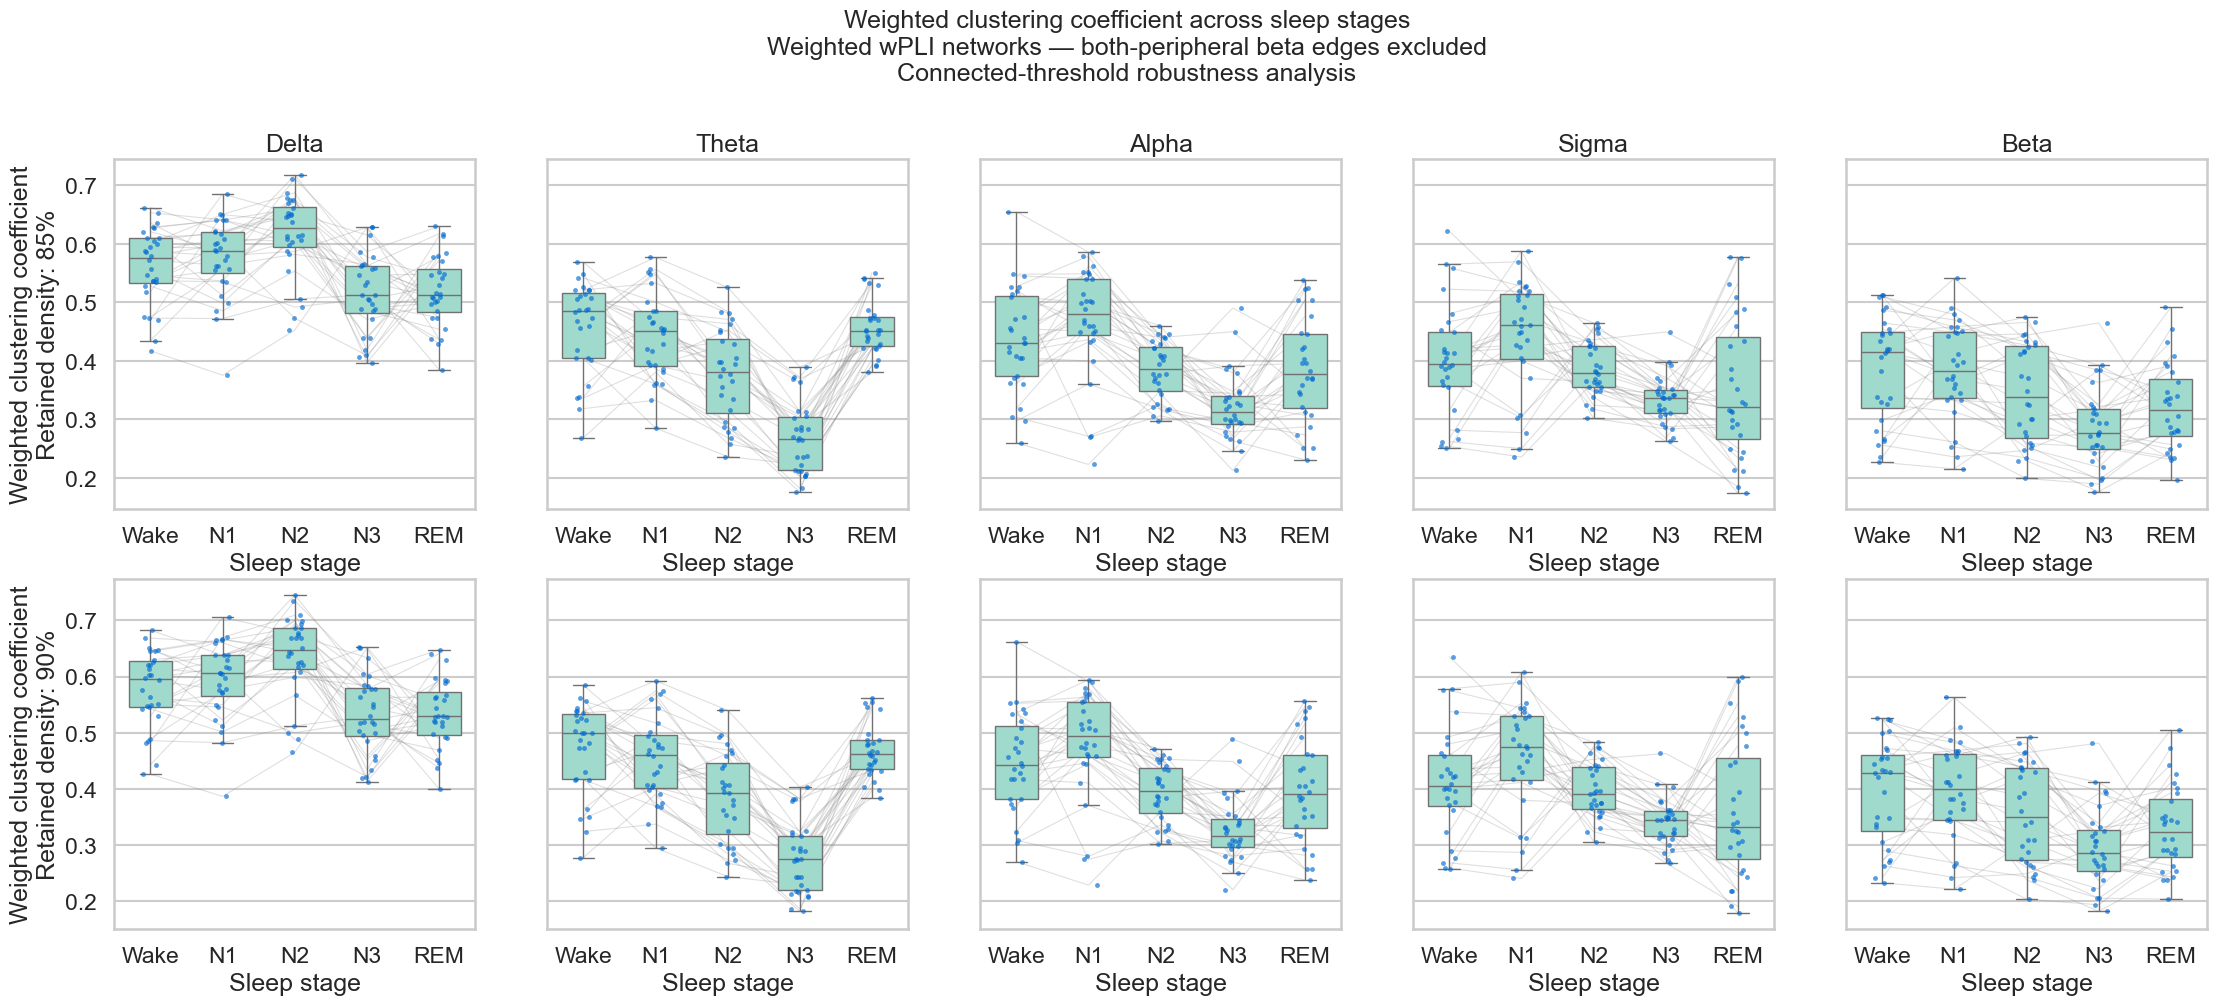

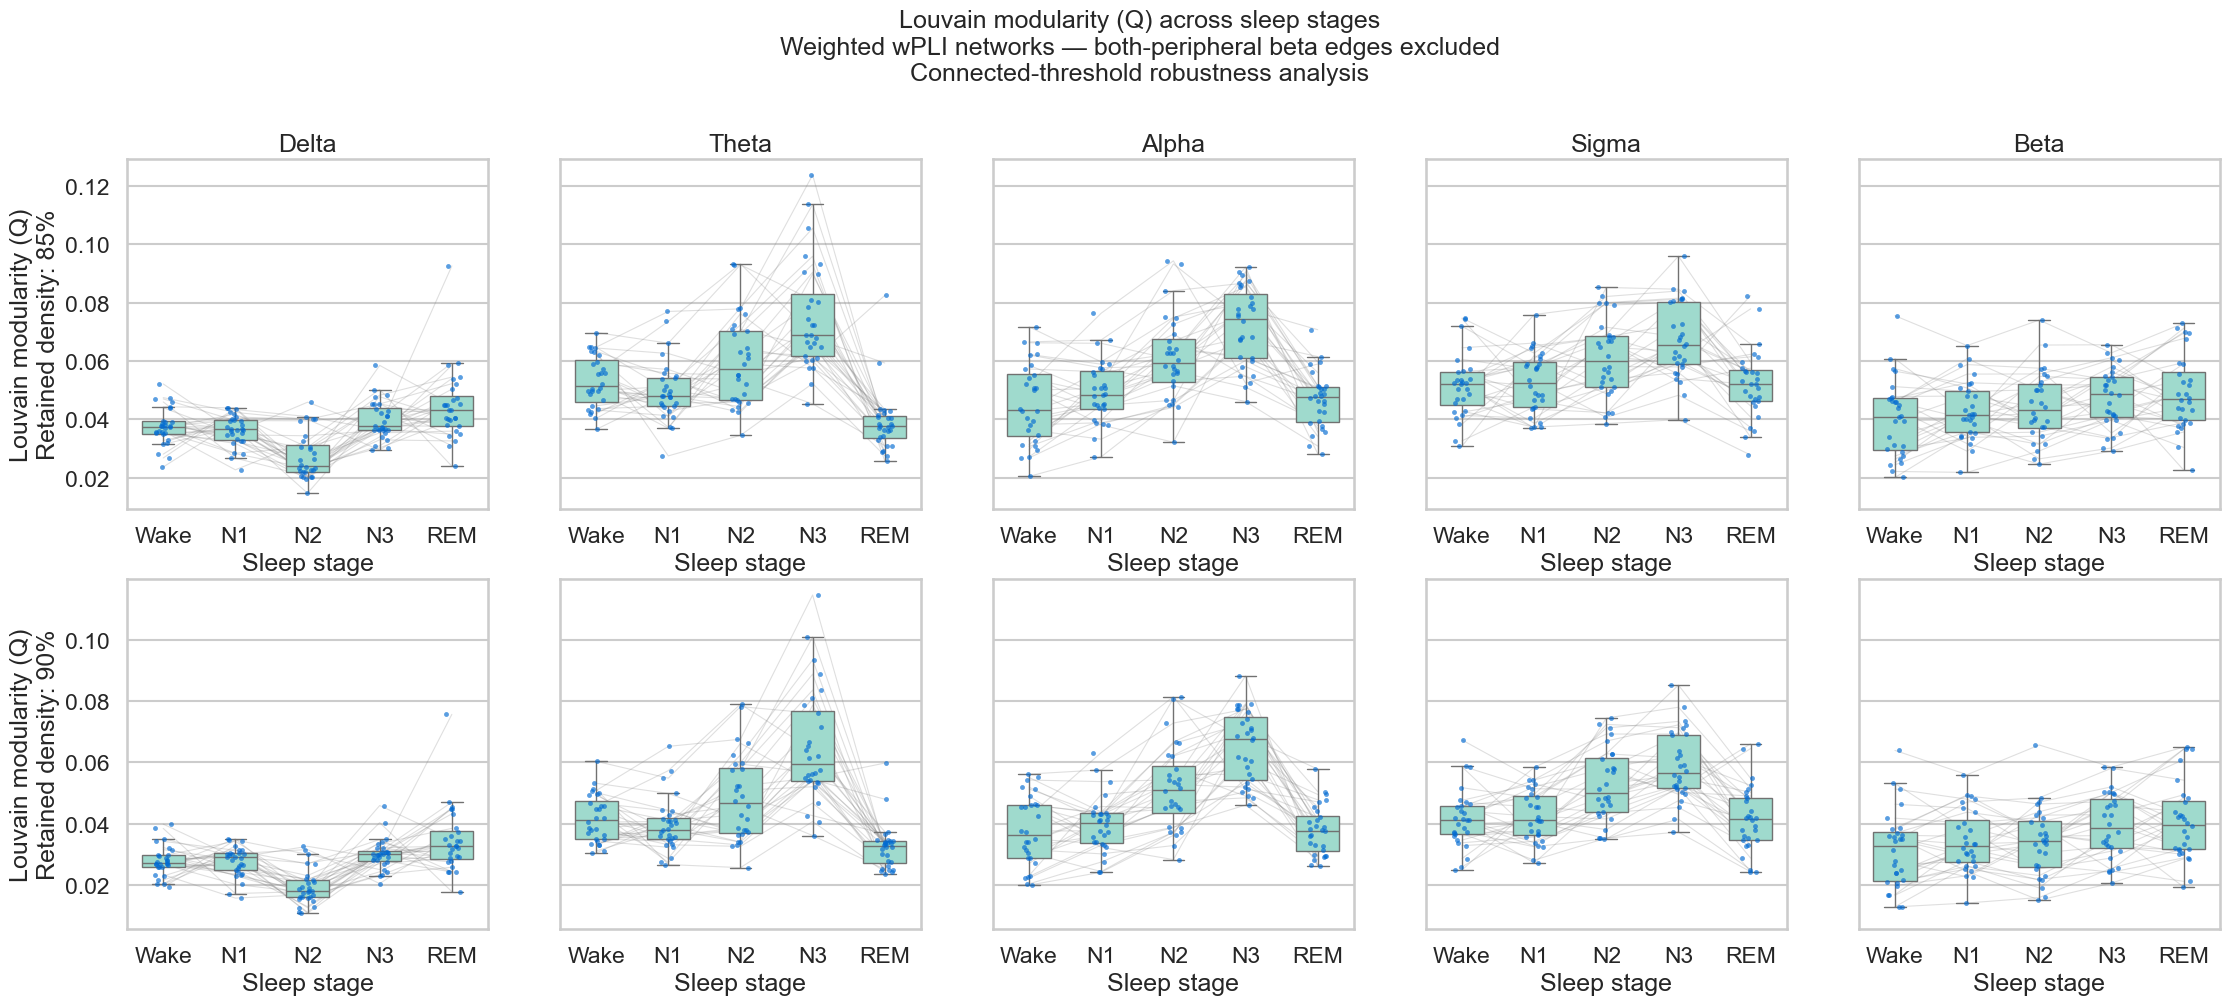

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

sns.set_theme(style="whitegrid", context="talk")

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]
CONNECTED_DENSITIES = [0.85, 0.90]


# ------------------------------------------------------------------
# Load / prepare connected-threshold results
# ------------------------------------------------------------------

# This dataframe should already exist after your thresholded-metrics cell:
metrics_to_plot = threshold_metrics_connected.copy()

# Your threshold code uses "subjectid", while your earlier unthresholded
# plotting code used "subject_id". Standardize the name for plotting.
if "subjectid" in metrics_to_plot.columns:
    metrics_to_plot = metrics_to_plot.rename(
        columns={"subjectid": "subject_id"}
    )

if "betaedgemode" in metrics_to_plot.columns:
    metrics_to_plot = metrics_to_plot.rename(
        columns={"betaedgemode": "beta_edge_mode"}
    )

if "nepochsaveraged" in metrics_to_plot.columns:
    metrics_to_plot = metrics_to_plot.rename(
        columns={"nepochsaveraged": "n_epochs_averaged"}
    )

# Keep only the two connected thresholds.
metrics_to_plot = metrics_to_plot.loc[
    metrics_to_plot["requested_density"].isin(CONNECTED_DENSITIES)
].copy()

# Safety checks.
assert metrics_to_plot["fully_connected"].all(), (
    "This plotting cell requires fully connected 85% and 90% graphs."
)

assert (
    metrics_to_plot["n_connected_components"] == 1
).all(), "Unexpected disconnected graph found."

assert (
    metrics_to_plot["largest_component_size"] == 83
).all(), "A connected graph does not contain all 83 nodes."

print("Beta-edge mode plotted:")
print(metrics_to_plot["beta_edge_mode"].unique())

print("\nGraphs per density:")
display(
    metrics_to_plot
    .groupby("requested_density")
    .size()
    .rename("n_graphs")
    .reset_index()
)


# ------------------------------------------------------------------
# Metrics to plot
# ------------------------------------------------------------------

# The first two are the primary connected-threshold integration results.
# The final two are optional thresholded-topology robustness figures.
PLOT_METRICS = {
    "weighted_global_efficiency": "Weighted global efficiency",
    "weighted_characteristic_path_length":
        "Weighted characteristic path length",
    "mean_weighted_clustering":
        "Weighted clustering coefficient",
    "modularity_louvain":
        "Louvain modularity (Q)",
}


# ------------------------------------------------------------------
# Plot one figure per metric
# Rows = density thresholds; columns = frequency bands
# ------------------------------------------------------------------

for metric_name, metric_label in PLOT_METRICS.items():

    fig, axes = plt.subplots(
        nrows=len(CONNECTED_DENSITIES),
        ncols=len(BAND_ORDER),
        figsize=(27, 10),
        sharey="row",
        constrained_layout=False,
    )

    for density_index, density in enumerate(CONNECTED_DENSITIES):

        density_data = metrics_to_plot.loc[
            metrics_to_plot["requested_density"] == density
        ].copy()

        for band_index, band in enumerate(BAND_ORDER):

            ax = axes[density_index, band_index]

            band_data = density_data.loc[
                density_data["band"] == band
            ].copy()

            if band_data.empty:
                ax.set_visible(False)
                continue

            # One gray within-participant trajectory per subject.
            for _, subject_data in band_data.groupby("subject_id"):

                subject_values = (
                    subject_data
                    .set_index("stage")[metric_name]
                    .reindex(STAGE_ORDER)
                )

                ax.plot(
                    np.arange(len(STAGE_ORDER)),
                    subject_values,
                    color="gray",
                    alpha=0.25,
                    linewidth=0.8,
                    zorder=1,
                )

            # Distribution across the 28 participants.
            sns.boxplot(
                data=band_data,
                x="stage",
                y=metric_name,
                order=STAGE_ORDER,
                ax=ax,
                color="#95e4d2",
                width=0.60,
                showfliers=False,
                zorder=2,
            )

            # Each individual participant's value.
            sns.stripplot(
                data=band_data,
                x="stage",
                y=metric_name,
                order=STAGE_ORDER,
                ax=ax,
                color="#016ad2",
                alpha=0.65,
                size=3.5,
                jitter=0.12,
                zorder=3,
            )

            # Column titles only on the top row.
            if density_index == 0:
                ax.set_title(band.capitalize())

            ax.set_xlabel("Sleep stage")

            # Y-axis label only in the first column of each density row.
            if band_index == 0:
                ax.set_ylabel(
                    f"{metric_label}\n"
                    f"Retained density: {density:.0%}"
                )
            else:
                ax.set_ylabel("")

    fig.suptitle(
        f"{metric_label} across sleep stages\n"
        "Weighted wPLI networks — both-peripheral beta edges excluded\n"
        "Connected-threshold robustness analysis",
        y=1.03,
        fontsize=18,
    )

    plt.show()

**Integration findings:**

The main integration result is that the sleep-stage patterns look almost the same at both 85% and 90% density. That means the findings are not dependent on one arbitrary threshold choice.

*Higher global efficiency and lower path length mean the network is more integrated: information can travel through stronger/shorter weighted routes. Lower global efficiency and higher path length mean the network is less integrated.*

**Main patterns**

- Delta: Integration is relatively high in Wake and N2, lower in N1, and lowest in REM.
- Theta: Integration changes only modestly across stages.
- Alpha: REM tends to show lower integration; Wake and N3 are relatively more integrated but variable between participants.
- Sigma: The clearest pattern—networks are most integrated in N2/N3 and least integrated in REM.
- Beta: Integration generally falls from Wake toward N2/N3, then partly recovers in REM; individual variability is large.

**Bottom line**
The strongest descriptive finding is:

Sigma networks become more integrated during N2/N3 and less integrated in REM.

There is also evidence for reduced REM integration in delta and alpha, while theta is relatively stable. Because the patterns appear at both 85% and 90%, they are robust to the connected-threshold choice.

**What clustering adds**

The clustering panels describe local segregation—how strongly a node’s neighbours tend to interconnect.

Broadly:

- Band	Visible clustering pattern
- Delta	Highest around N2; lower in N3/REM
- Theta	Declines toward N3; increases again in REM
- Alpha	Lower around N3; variable in Wake/N1
- Sigma	Higher in N1; lower in N3 and often REM
- Beta	Variable, with lower clustering around N3

These patterns are very similar at 85% and 90%, so they also appear threshold-stable. However, clustering is supplementary here; your connected-threshold primary focus remains integration.

**What modularity adds**

Louvain modularity reflects the degree to which the graph separates into relatively distinct weighted communities.

The broad pattern is:

**Theta, alpha, sigma:**
Modularity often rises from Wake/N1 toward N2/N3,
then declines in REM.

**Delta:**
N2 has notably lower modularity than the other stages.

**Beta:**
Modularity differences are comparatively small and variable.
A potential interpretation is that theta/alpha/sigma networks become more segregated into community-like weighted structure around N2/N3, then become less modular in REM. But this should remain an optional supplementary result, since modularity is sensitive to graph density, community-detection choices, and the exact network representation

**CONCLUSIONS UP TO NOW:**

Across all 700 subject × stage × band networks, 85% and 90% proportional thresholds preserved full connectivity. Stage-related patterns in global efficiency and characteristic path length were qualitatively similar across both densities, supporting the robustness of the integration findings to connected-threshold selection.

You can also state, more specifically:

- Delta and sigma show clear stage-related integration changes.

- REM often shows reduced integration in delta, alpha, and sigma.

- Sigma appears most integrated in N2/N3.

- Beta shows reduced integration around N2/N3, with large individual variation.

- Theta shows comparatively modest stage dependence.

Beta-edge mode plotted:
<StringArray>
['exclude_both_peripheral']
Length: 1, dtype: str

Graphs per sparse density:


,requested_density,n_graphs
0,0.1,700
1,0.2,700
2,0.3,700



Sparse-threshold component QC by density, band, and stage:


,requested_density,band,stage,n_graphs,proportion_fully_connected,mean_components,median_components,max_components,mean_largest_component,min_largest_component
0,0.1,alpha,N1,28,0.000000,18.500000,18.0,34,65.071429,45
1,0.1,alpha,N2,28,0.000000,20.071429,18.5,38,63.571429,46
2,0.1,alpha,N3,28,0.000000,21.071429,21.0,31,62.571429,51
3,0.1,alpha,REM,28,0.035714,16.535714,17.5,39,67.214286,45
4,0.1,alpha,Wake,28,0.000000,21.714286,21.5,40,61.714286,44
...,...,...,...,...,...,...,...,...,...,...
70,0.3,theta,N1,28,0.142857,3.392857,3.0,6,80.178571,77
71,0.3,theta,N2,28,0.142857,4.035714,3.5,10,79.535714,74
72,0.3,theta,N3,28,0.392857,1.964286,2.0,5,81.642857,78
73,0.3,theta,REM,28,0.107143,4.571429,5.0,13,79.071429,71


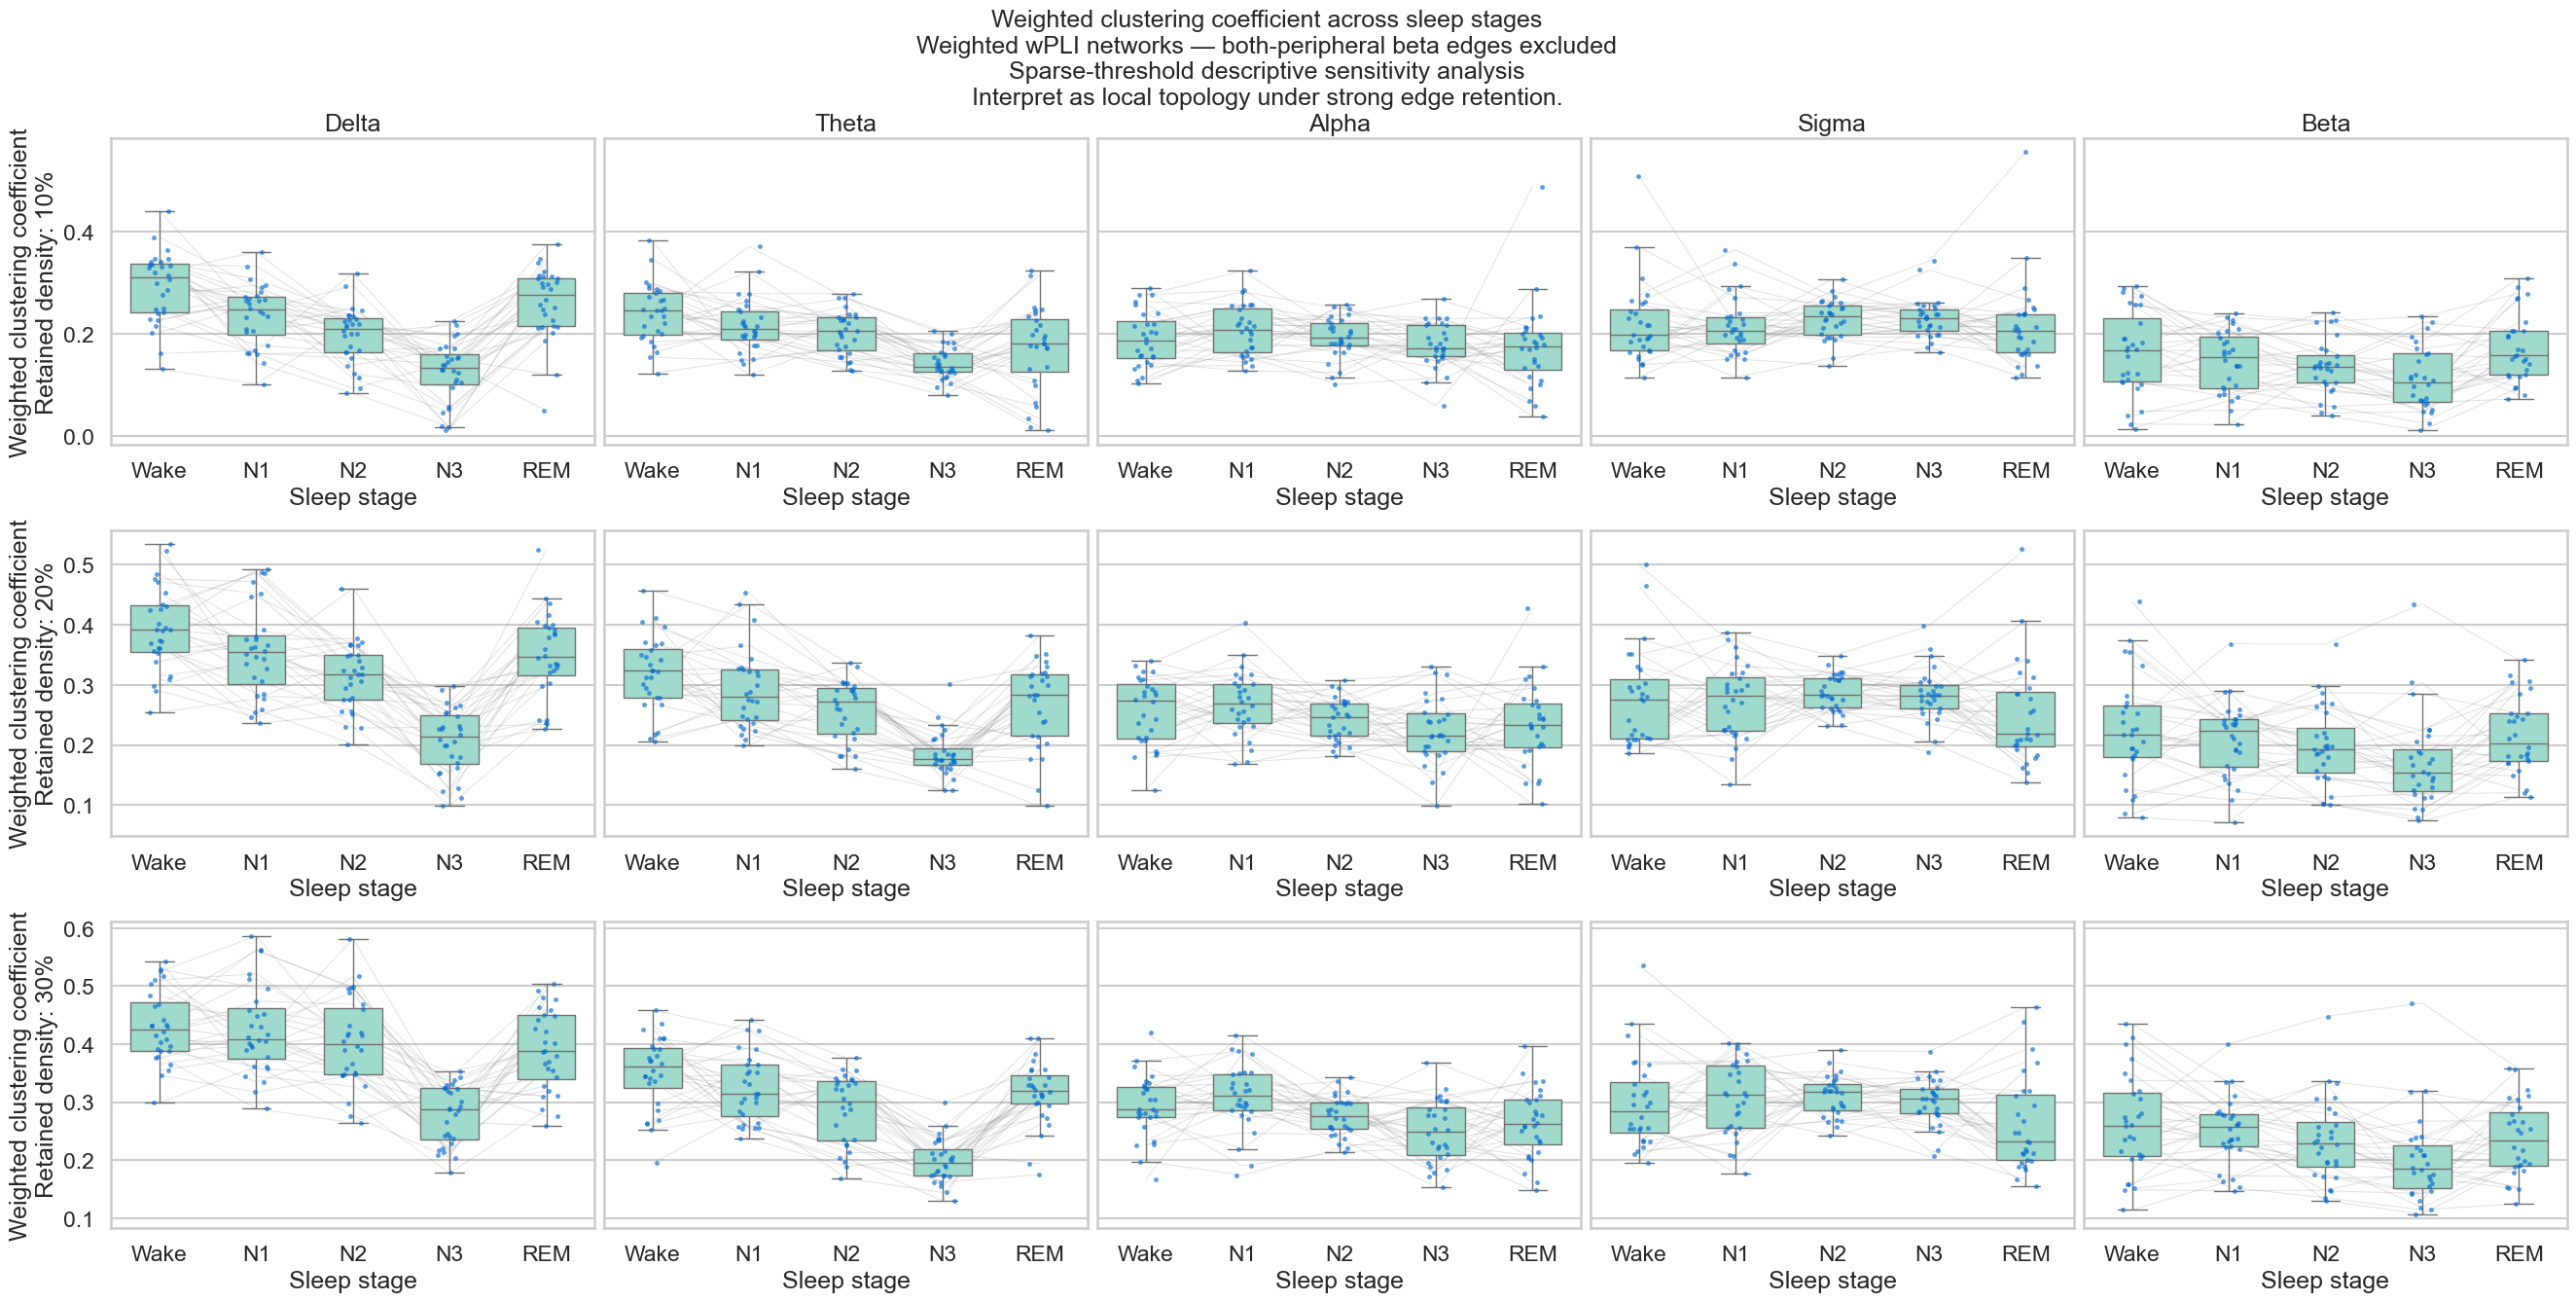

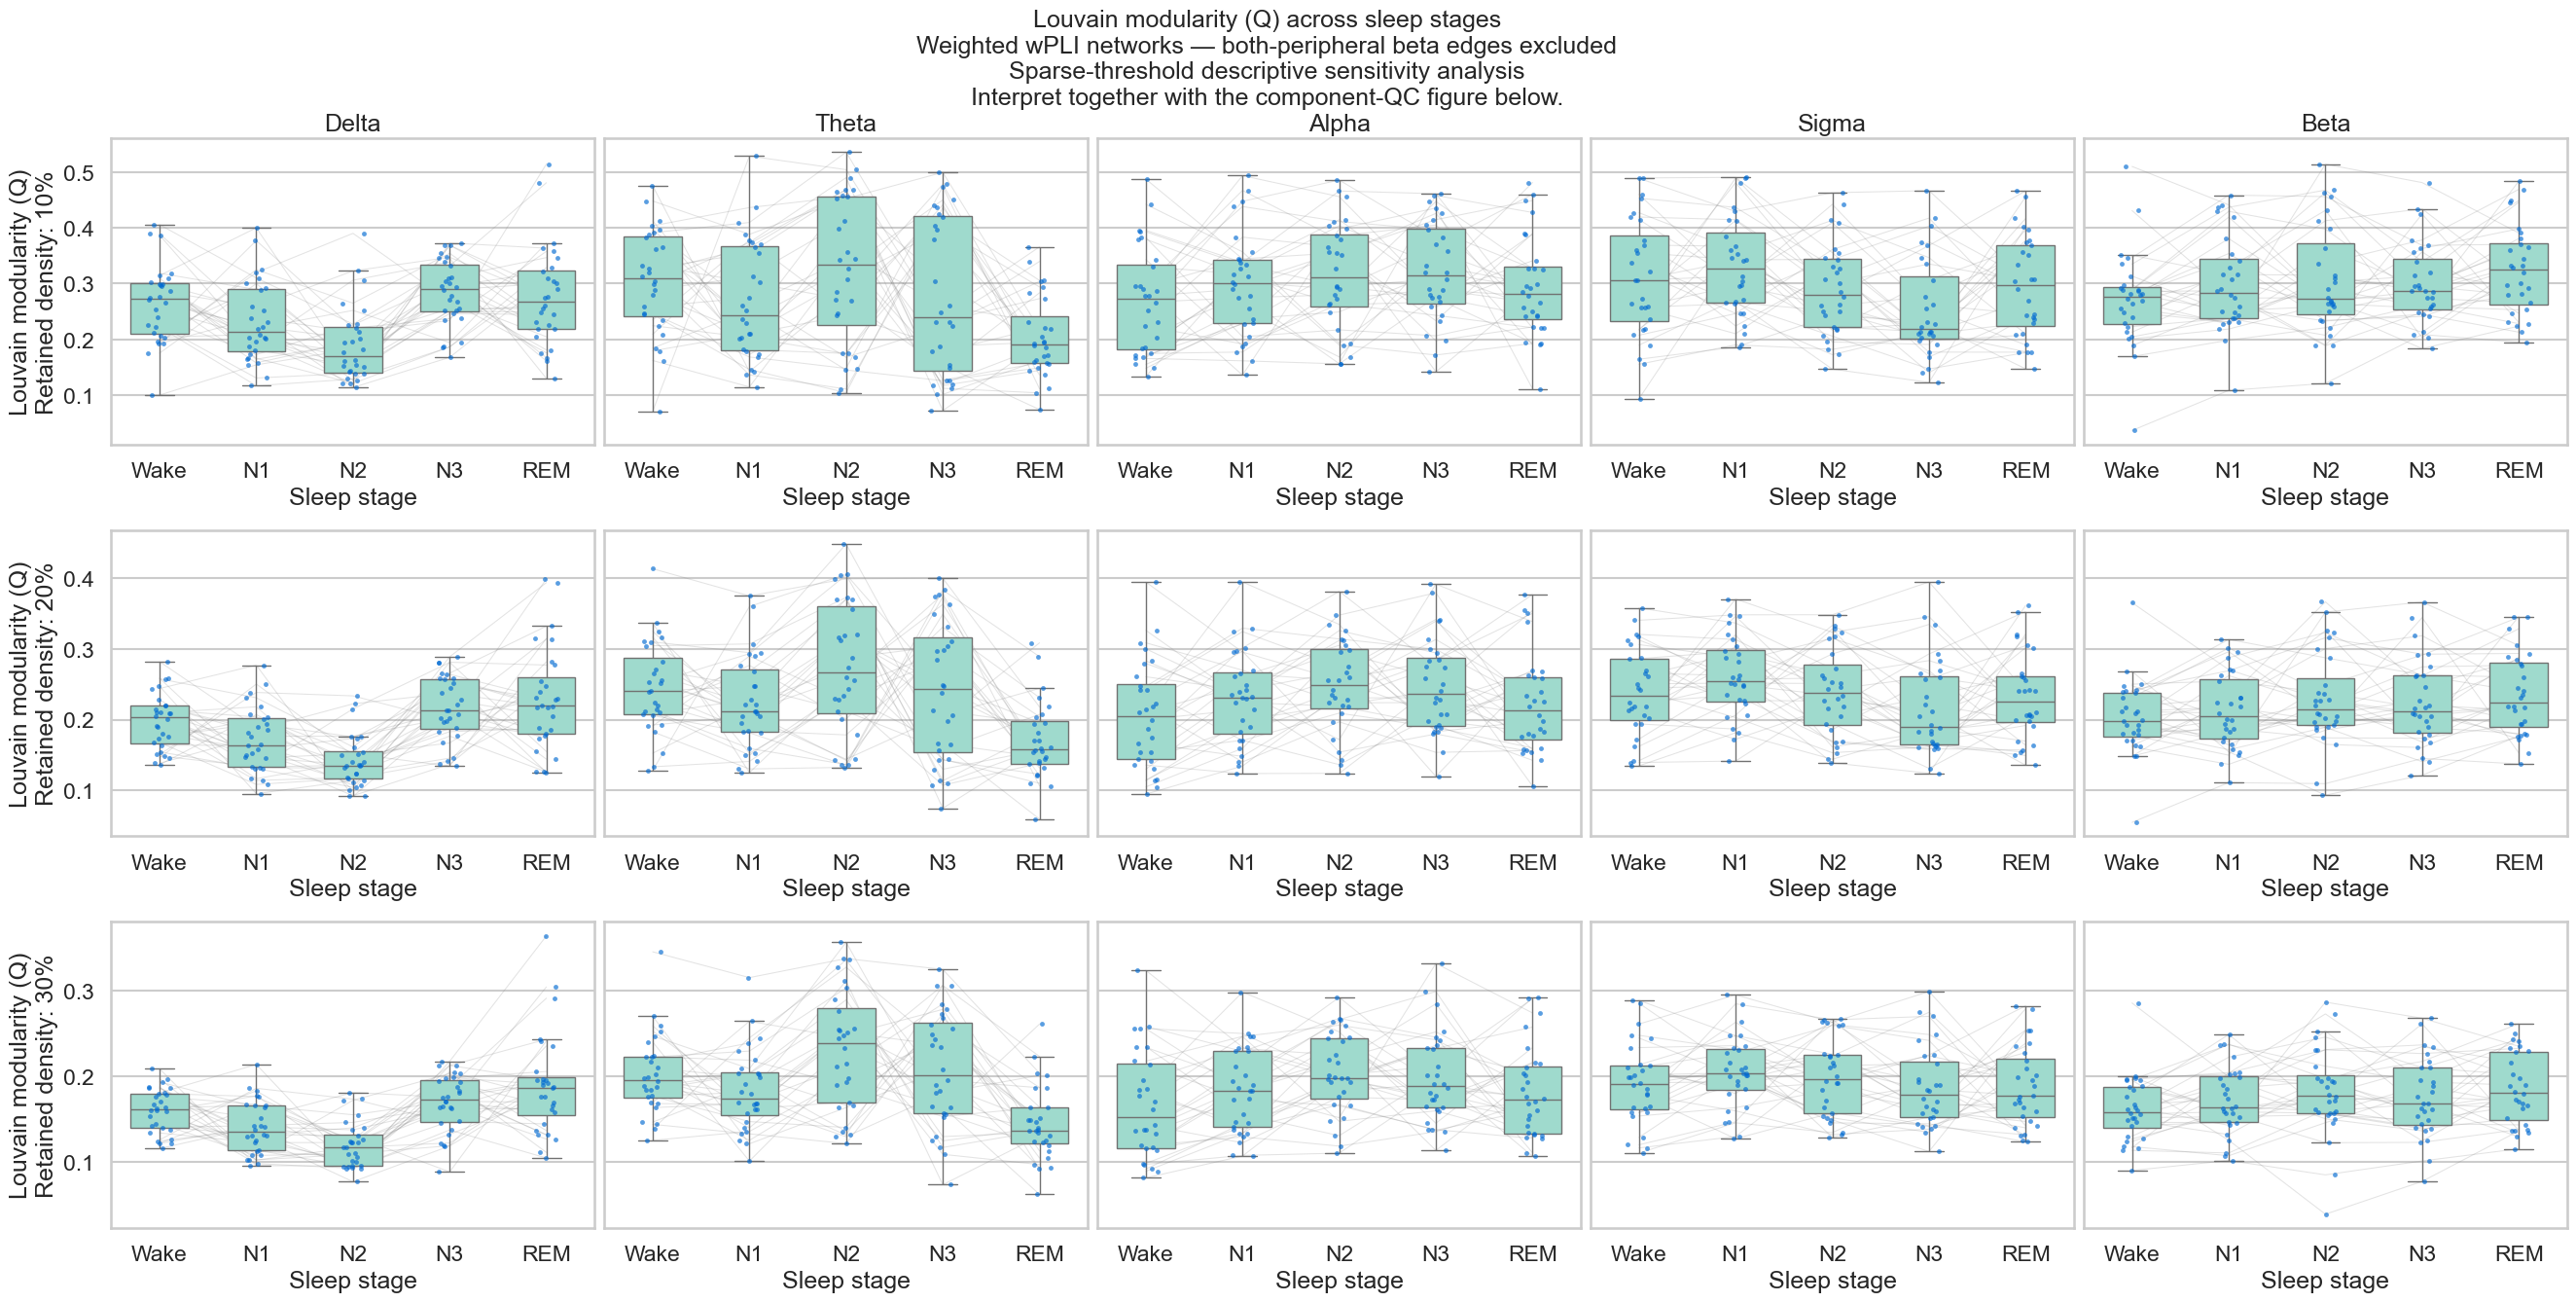

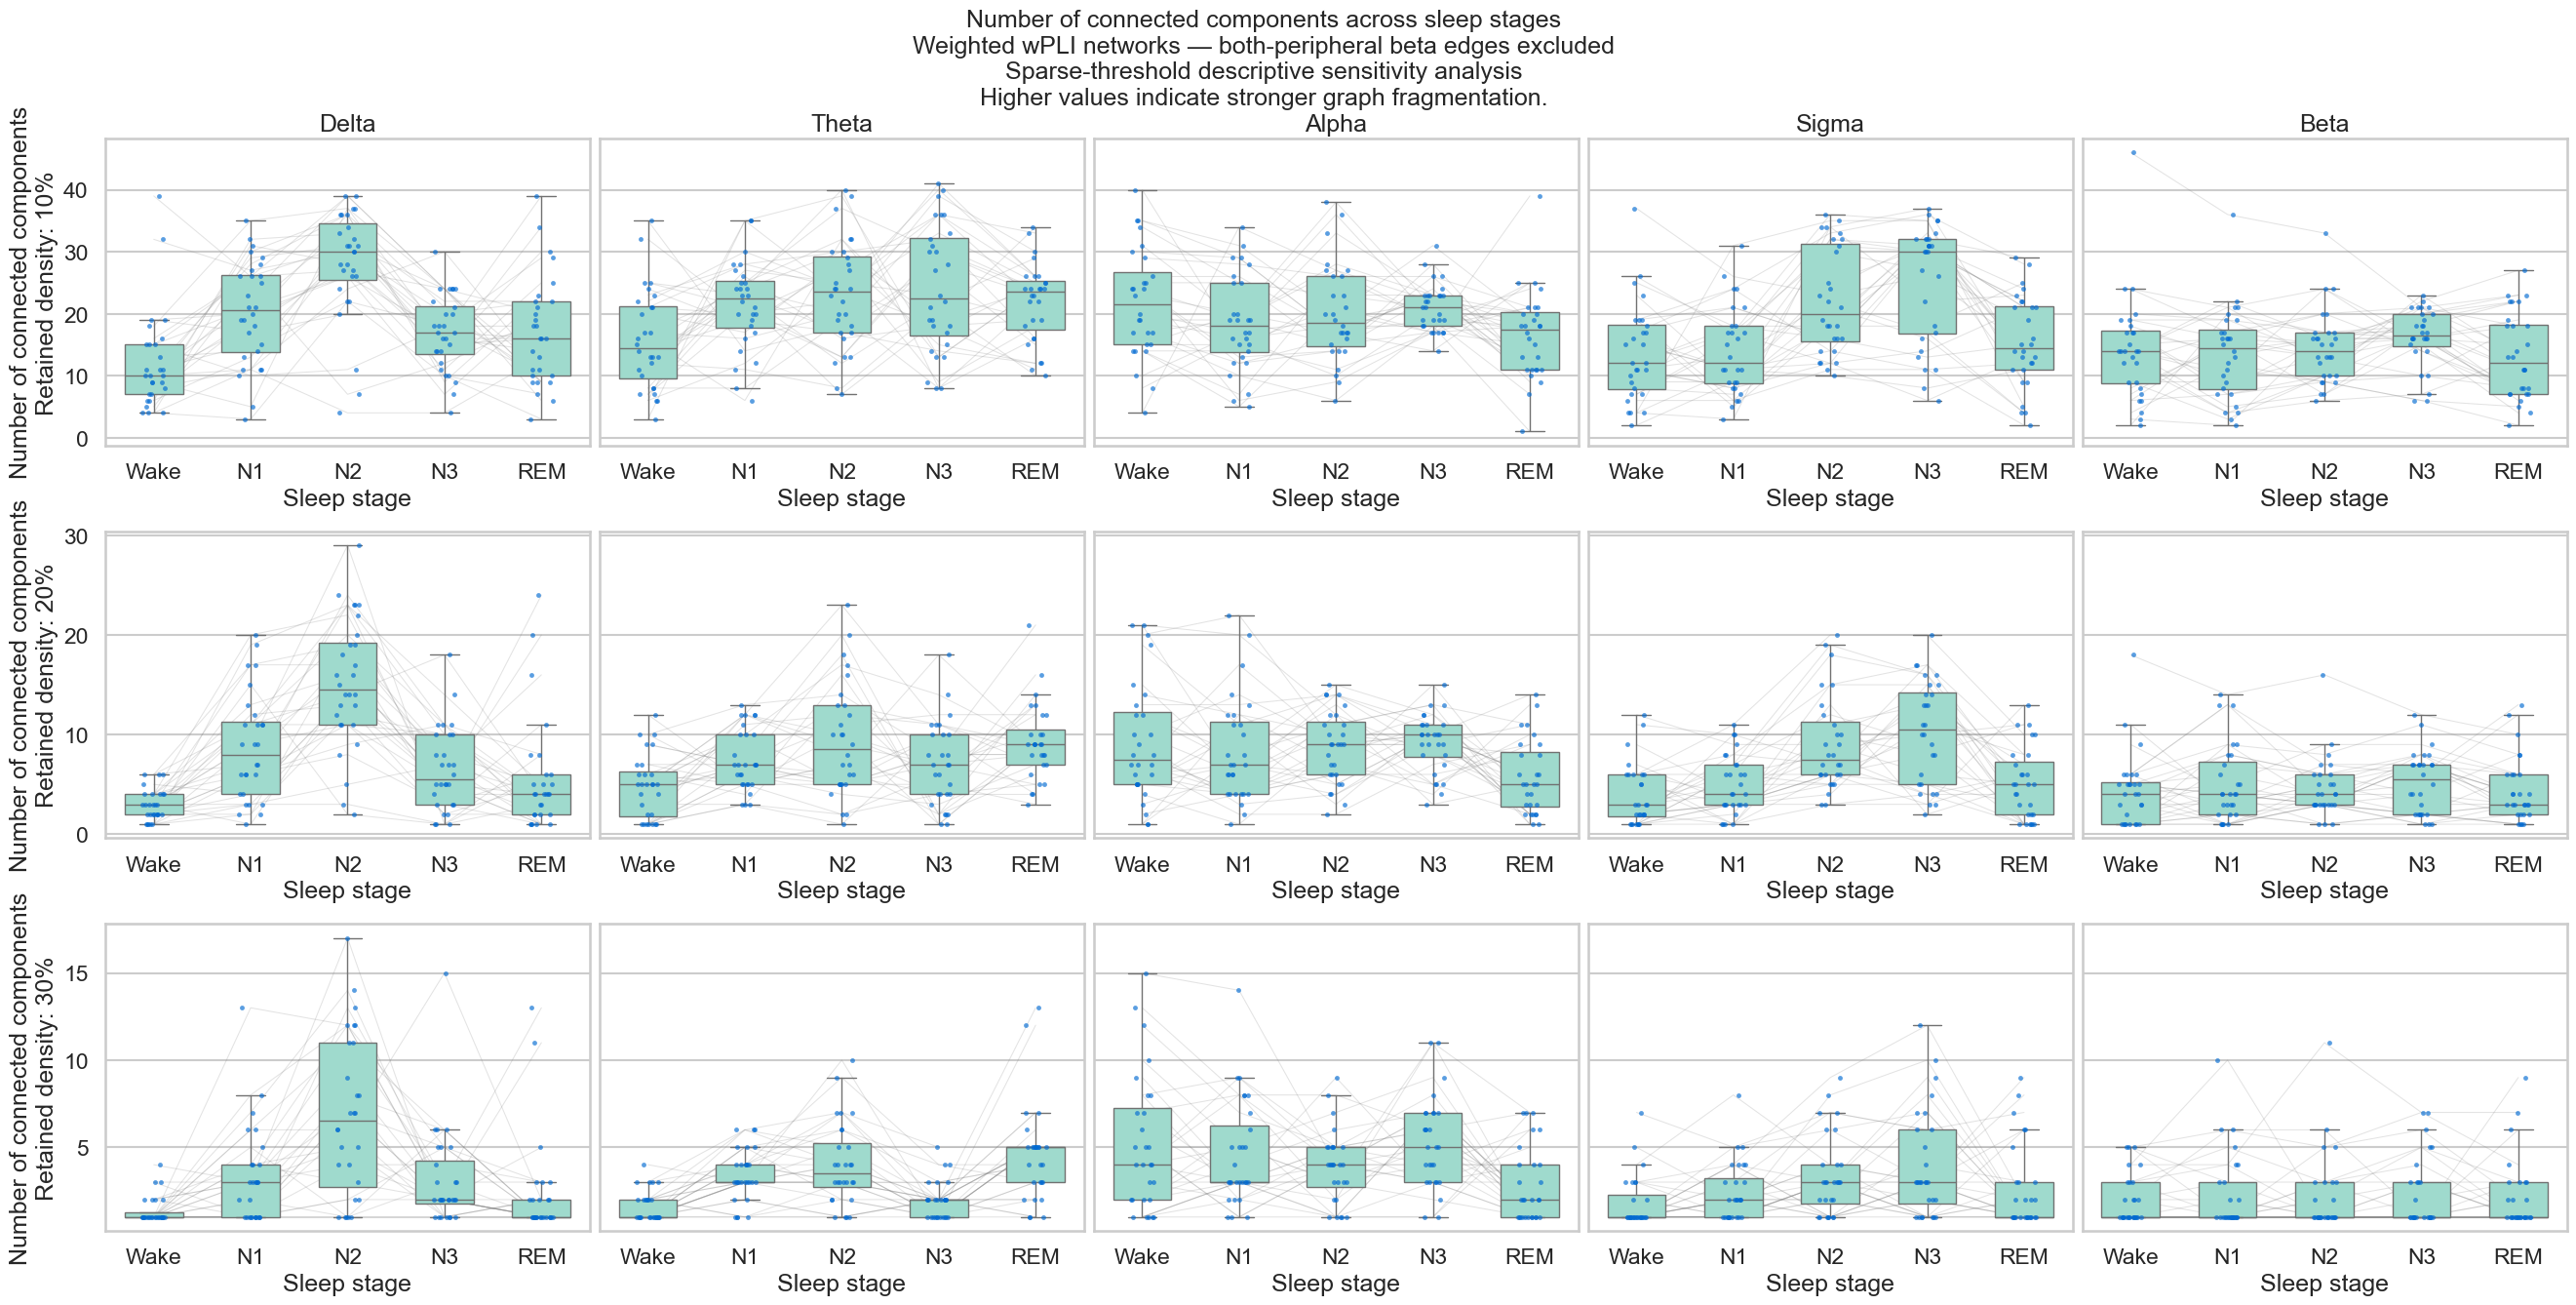

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

sns.set_theme(style="whitegrid", context="talk")

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]
SPARSE_DENSITIES = [0.10, 0.20, 0.30]


# ------------------------------------------------------------------
# Prepare sparse-threshold dataframe
# ------------------------------------------------------------------

metrics_sparse_to_plot = threshold_metrics_sparse.copy()

# Standardize column names so this code remains compatible with
# the unthresholded plotting code too.
if "subjectid" in metrics_sparse_to_plot.columns:
    metrics_sparse_to_plot = metrics_sparse_to_plot.rename(
        columns={"subjectid": "subject_id"}
    )

if "betaedgemode" in metrics_sparse_to_plot.columns:
    metrics_sparse_to_plot = metrics_sparse_to_plot.rename(
        columns={"betaedgemode": "beta_edge_mode"}
    )

if "nepochsaveraged" in metrics_sparse_to_plot.columns:
    metrics_sparse_to_plot = metrics_sparse_to_plot.rename(
        columns={"nepochsaveraged": "n_epochs_averaged"}
    )

metrics_sparse_to_plot = metrics_sparse_to_plot.loc[
    metrics_sparse_to_plot["requested_density"].isin(SPARSE_DENSITIES)
].copy()

assert set(
    metrics_sparse_to_plot["requested_density"].unique()
) == set(SPARSE_DENSITIES)

assert (
    metrics_sparse_to_plot["analysis_set"] == "sparse"
).all()

print("Beta-edge mode plotted:")
print(metrics_sparse_to_plot["beta_edge_mode"].unique())

print("\nGraphs per sparse density:")
display(
    metrics_sparse_to_plot
    .groupby("requested_density")
    .size()
    .rename("n_graphs")
    .reset_index()
)


# ------------------------------------------------------------------
# Component quality-control table
# ------------------------------------------------------------------

sparse_component_qc = (
    metrics_sparse_to_plot
    .groupby(["requested_density", "band", "stage"])
    .agg(
        n_graphs=("subject_id", "size"),
        proportion_fully_connected=("fully_connected", "mean"),
        mean_components=("n_connected_components", "mean"),
        median_components=("n_connected_components", "median"),
        max_components=("n_connected_components", "max"),
        mean_largest_component=(
            "largest_component_size",
            "mean",
        ),
        min_largest_component=(
            "largest_component_size",
            "min",
        ),
    )
    .reset_index()
)

print("\nSparse-threshold component QC by density, band, and stage:")
display(sparse_component_qc)


# ------------------------------------------------------------------
# Reusable plotting function
# ------------------------------------------------------------------

def plot_sparse_metric(
    data,
    metric_name,
    metric_label,
    title_note="",
    y_scale="linear",
):
    """
    Rows = sparse density thresholds
    Columns = frequency bands
    Each panel shows participant trajectories, boxplots, and points.
    """

    fig, axes = plt.subplots(
        nrows=len(SPARSE_DENSITIES),
        ncols=len(BAND_ORDER),
        figsize=(27, 14),
        sharey="row",
        constrained_layout=False,
    )

    for density_index, density in enumerate(SPARSE_DENSITIES):

        density_data = data.loc[
            data["requested_density"] == density
        ].copy()

        for band_index, band in enumerate(BAND_ORDER):

            ax = axes[density_index, band_index]

            band_data = density_data.loc[
                density_data["band"] == band
            ].copy()

            if band_data.empty:
                ax.set_visible(False)
                continue

            # Participant-level repeated-measure trajectories.
            for _, subject_data in band_data.groupby("subject_id"):

                subject_values = (
                    subject_data
                    .set_index("stage")[metric_name]
                    .reindex(STAGE_ORDER)
                )

                ax.plot(
                    np.arange(len(STAGE_ORDER)),
                    subject_values,
                    color="gray",
                    alpha=0.22,
                    linewidth=0.75,
                    zorder=1,
                )

            # Group distribution.
            sns.boxplot(
                data=band_data,
                x="stage",
                y=metric_name,
                order=STAGE_ORDER,
                ax=ax,
                color="#95e4d2",
                width=0.60,
                showfliers=False,
                zorder=2,
            )

            # Individual participant values.
            sns.stripplot(
                data=band_data,
                x="stage",
                y=metric_name,
                order=STAGE_ORDER,
                ax=ax,
                color="#016ad2",
                alpha=0.65,
                size=3.5,
                jitter=0.12,
                zorder=3,
            )

            if density_index == 0:
                ax.set_title(band.capitalize())

            ax.set_xlabel("Sleep stage")
            ax.set_yscale(y_scale)

            if band_index == 0:
                ax.set_ylabel(
                    f"{metric_label}\n"
                    f"Retained density: {density:.0%}"
                )
            else:
                ax.set_ylabel("")

    fig.subplots_adjust(
        top=0.88,
        bottom=0.08,
        left=0.06,
        right=0.995,
        hspace=0.28,
        wspace=0.02,
    )

    fig.suptitle(
        f"{metric_label} across sleep stages\n"
        "Weighted wPLI networks — both-peripheral beta edges excluded\n"
        f"Sparse-threshold descriptive sensitivity analysis"
        f"{title_note}",
        y=0.975,
        fontsize=18,
    )

    plt.show()


# ------------------------------------------------------------------
# Sparse weighted clustering
# ------------------------------------------------------------------

plot_sparse_metric(
    data=metrics_sparse_to_plot,
    metric_name="mean_weighted_clustering",
    metric_label="Weighted clustering coefficient",
    title_note=(
        "\nInterpret as local topology under strong edge retention."
    ),
)


# ------------------------------------------------------------------
# Sparse Louvain modularity
# ------------------------------------------------------------------

plot_sparse_metric(
    data=metrics_sparse_to_plot,
    metric_name="modularity_louvain",
    metric_label="Louvain modularity (Q)",
    title_note=(
        "\nInterpret together with the component-QC figure below."
    ),
)


# ------------------------------------------------------------------
# Sparse component QC figure
# ------------------------------------------------------------------

plot_sparse_metric(
    data=metrics_sparse_to_plot,
    metric_name="n_connected_components",
    metric_label="Number of connected components",
    title_note=(
        "\nHigher values indicate stronger graph fragmentation."
    ),
)

This is a very useful result because it makes the limitation of the sparse-threshold analysis explicit: at 10%, 20%, and often 30%, the graphs are fragmented in a stage- and band-dependent way. Therefore, the figures work well as descriptive sensitivity analyses, but they should not become your main evidence for modularity or sparse-network integration.

Thus, even at 30%, connectivity differs substantially by sleep stage. That may reflect differences in the distribution of the strongest edges, but it also means that a stage difference in modularity could partly arise from different degrees of threshold-induced fragmentation.

The **clustering** patterns are more useful than modularity at these sparse densities because clustering is a local measure.

Some patterns appear directionally consistent across 10%, 20%, and 30%:

| Band  | Descriptive sparse-clustering pattern                                                |
| ----- | ------------------------------------------------------------------------------------ |
| Delta | Relatively high in Wake/N1, falls markedly in N3, then rebounds in REM               |
| Theta | Generally declines from Wake toward N3, with a REM rebound                           |
| Alpha | More modest/variable stage differences; no equally strong common pattern             |
| Sigma | Stage pattern is variable across densities, especially at 10%                        |
| Beta  | Lower around N2/N3 and higher again in REM, but participant variation is substantial |

The clearest sparse-threshold clustering candidate is probably delta: N3 appears consistently lower than Wake, N1, and often REM across all three densities. Theta also shows a broadly similar N3 reduction and REM rebound.

“The local clustering pattern was qualitatively similar across sparse thresholds.”

However, at 10% and 20%, many of those graphs have many disconnected components. A disconnected component can be treated by Louvain as a separate community-like structure, artificially elevating or altering modularity. -->

“Sparse-threshold Louvain modularity showed stage-dependent descriptive variation, but interpretation is limited because the networks were frequently fragmented.”

At 10–30% retained density, clustering can be described as a local sparse-network sensitivity result, but modularity and community counts cannot be interpreted cleanly without accounting for severe and stage-dependent graph fragmentation.

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


sns.set_theme(style="whitegrid", context="talk")

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]

SPARSE_DENSITIES = [0.10, 0.20, 0.30]
CONNECTED_DENSITIES = [0.85, 0.90]


def standardize_threshold_columns(df):
    df = df.copy()

    rename_map = {
        "subjectid": "subject_id",
        "betaedgemode": "beta_edge_mode",
        "nepochsaveraged": "n_epochs_averaged",
    }

    existing_renames = {
        old: new
        for old, new in rename_map.items()
        if old in df.columns
    }

    return df.rename(columns=existing_renames)


connected_stability_data = standardize_threshold_columns(
    threshold_metrics_connected
)

sparse_stability_data = standardize_threshold_columns(
    threshold_metrics_sparse
)

connected_stability_data = connected_stability_data.loc[
    connected_stability_data["requested_density"].isin(
        CONNECTED_DENSITIES
    )
].copy()

sparse_stability_data = sparse_stability_data.loc[
    sparse_stability_data["requested_density"].isin(
        SPARSE_DENSITIES
    )
].copy()

assert connected_stability_data["fully_connected"].all()

print("Connected rows:", len(connected_stability_data))
print("Sparse rows:", len(sparse_stability_data))

Connected rows: 1400
Sparse rows: 2100


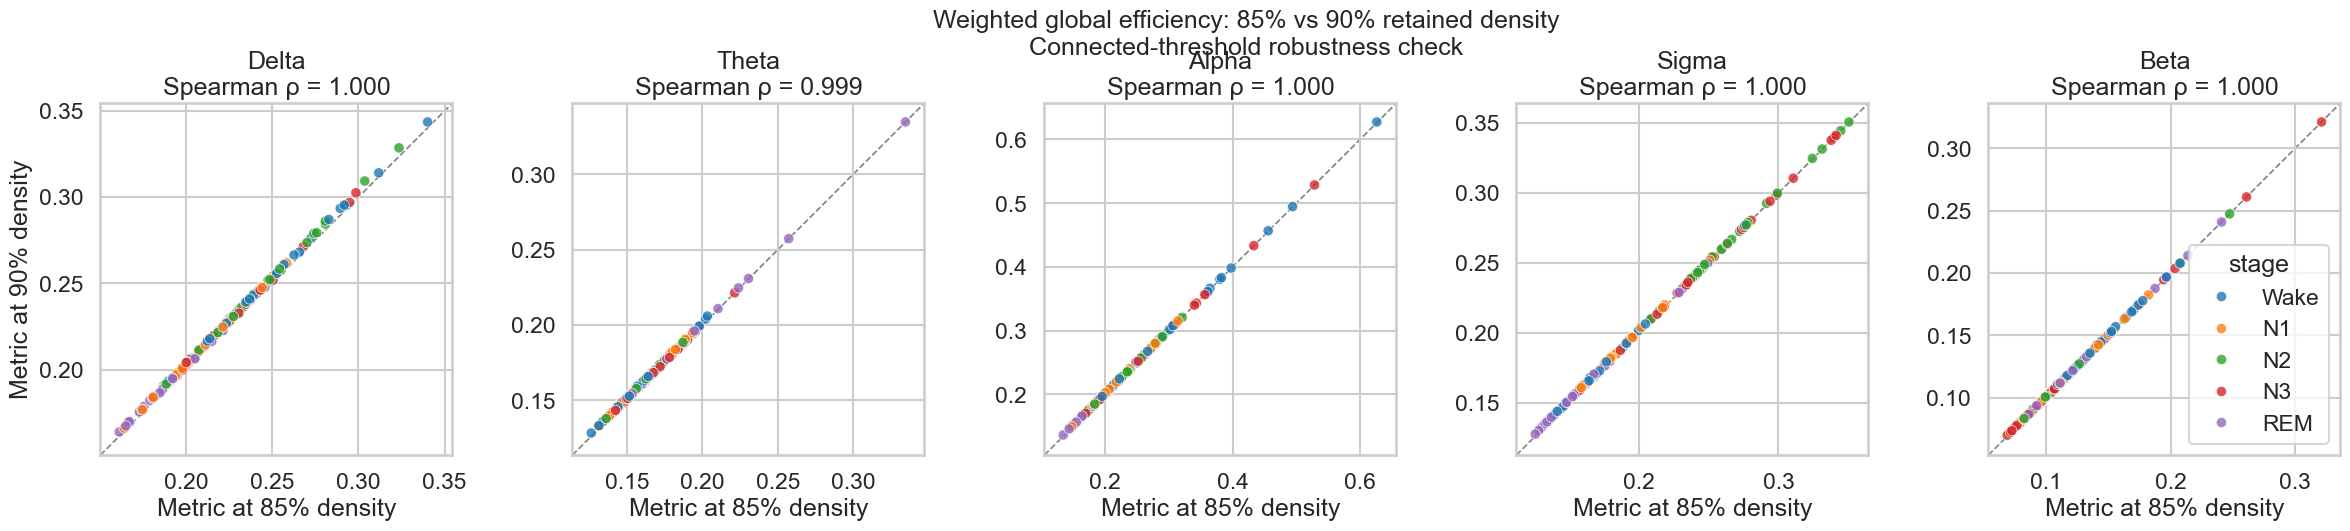


Weighted global efficiency: 85%-vs-90% stability summary


,metric,band,n_graphs,spearman_rho_85_vs_90,spearman_p_85_vs_90
0,weighted_global_efficiency,delta,140,0.999550,4.989147e-212
1,weighted_global_efficiency,theta,140,0.999156,3.235798e-193
2,weighted_global_efficiency,alpha,140,0.999781,1.108058e-233
3,weighted_global_efficiency,sigma,140,0.999746,3.102089e-229
4,weighted_global_efficiency,beta,140,0.999886,2.820466e-253


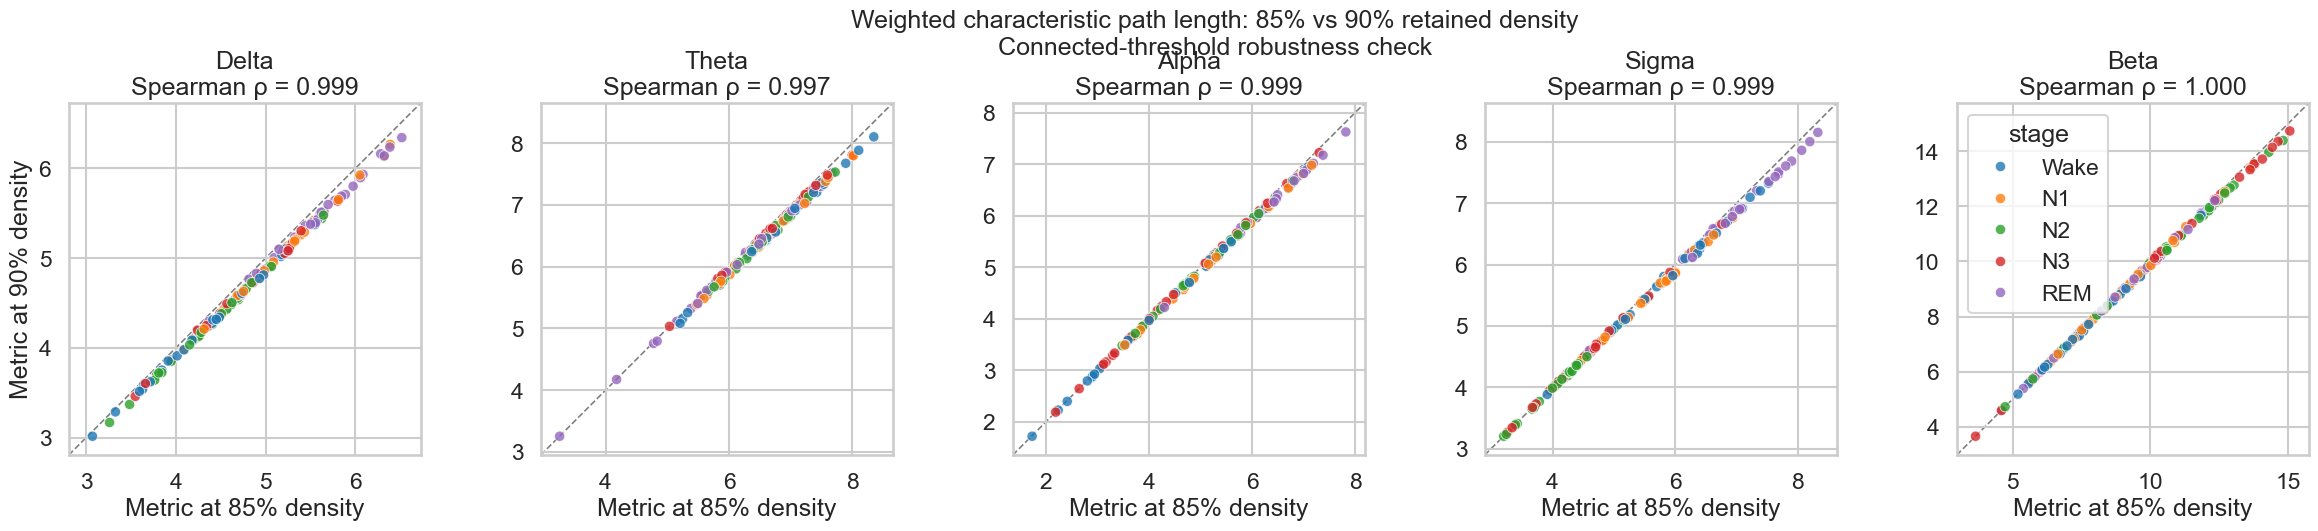


Weighted characteristic path length: 85%-vs-90% stability summary


,metric,band,n_graphs,spearman_rho_85_vs_90,spearman_p_85_vs_90
0,weighted_characteristic_path_length,delta,140,0.999112,1.054671e-191
1,weighted_characteristic_path_length,theta,140,0.997350,5.899649e-159
2,weighted_characteristic_path_length,alpha,140,0.999213,2.637289e-195
3,weighted_characteristic_path_length,sigma,140,0.999261,3.405948e-197
4,weighted_characteristic_path_length,beta,140,0.999532,6.910091e-211


In [18]:
from scipy.stats import spearmanr


CONNECTED_STABILITY_METRICS = {
    "weighted_global_efficiency": "Weighted global efficiency",
    "weighted_characteristic_path_length":
        "Weighted characteristic path length",
}


for metric_name, metric_label in CONNECTED_STABILITY_METRICS.items():

    fig, axes = plt.subplots(
        1,
        len(BAND_ORDER),
        figsize=(26, 5.5),
        constrained_layout=False,
    )

    stability_rows = []

    for ax, band in zip(axes, BAND_ORDER):

        band_data = connected_stability_data.loc[
            connected_stability_data["band"] == band
        ].copy()

        wide_data = (
            band_data
            .pivot_table(
                index=["subject_id", "stage"],
                columns="requested_density",
                values=metric_name,
                aggfunc="first",
            )
            .reindex(columns=CONNECTED_DENSITIES)
            .dropna()
        )

        x = wide_data[0.85]
        y = wide_data[0.90]

        if len(wide_data) == 0:
            ax.set_visible(False)
            continue

        scatter_data = (
            wide_data
            .reset_index()
            .rename(
                columns={
                    0.85: "metric_85",
                    0.90: "metric_90",
                }
            )
        )

        sns.scatterplot(
            data=scatter_data,
            x="metric_85",
            y="metric_90",
            hue="stage",
            hue_order=STAGE_ORDER,
            palette="tab10",
            s=55,
            alpha=0.80,
            ax=ax,
            legend=(band == BAND_ORDER[-1]),
        )

        lower_limit = min(x.min(), y.min())
        upper_limit = max(x.max(), y.max())
        padding = (upper_limit - lower_limit) * 0.06

        if padding == 0:
            padding = 0.01

        plot_min = lower_limit - padding
        plot_max = upper_limit + padding

        ax.plot(
            [plot_min, plot_max],
            [plot_min, plot_max],
            linestyle="--",
            linewidth=1.2,
            color="gray",
            zorder=0,
        )

        ax.set_xlim(plot_min, plot_max)
        ax.set_ylim(plot_min, plot_max)
        ax.set_aspect("equal", adjustable="box")

        rho, p_value = spearmanr(x, y)

        stability_rows.append(
            {
                "metric": metric_name,
                "band": band,
                "n_graphs": len(wide_data),
                "spearman_rho_85_vs_90": rho,
                "spearman_p_85_vs_90": p_value,
            }
        )

        ax.set_title(
            f"{band.capitalize()}\n"
            f"Spearman ρ = {rho:.3f}"
        )
        ax.set_xlabel("Metric at 85% density")

        if band == BAND_ORDER[0]:
            ax.set_ylabel("Metric at 90% density")
        else:
            ax.set_ylabel("")

        if band != BAND_ORDER[-1]:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

    fig.subplots_adjust(
        top=0.80,
        bottom=0.16,
        left=0.05,
        right=0.93,
        wspace=0.18,
    )

    fig.suptitle(
        f"{metric_label}: 85% vs 90% retained density\n"
        "Connected-threshold robustness check",
        y=0.97,
        fontsize=18,
    )

    plt.show()

    stability_summary = pd.DataFrame(stability_rows)

    print(f"\n{metric_label}: 85%-vs-90% stability summary")
    display(stability_summary)

**Interpreation:**

Weighted global efficiency and weighted characteristic path length were highly stable across the two fully connected proportional thresholds. Across all frequency bands, Spearman correlations between 85% and 90% density values ranged from 0.999 to 1.000 for global efficiency and from 0.997 to 1.000 for characteristic path length. Therefore, the observed sleep-stage integration patterns were robust to the connected-threshold choice.

Nuance: The tiny p-values are expected because the correlations are almost perfect and each band includes 140 graph observations. Do not treat these p-values as tests of your sleep-stage hypothesis. Their role is only: Threshold-stability evidence. The actual sleep-stage inference should still use participant-aware repeated-measures statistics, because the 140 values within a band are not 140 independent observations—they are 28 participants measured across five stages.

**Clean methodological narrative:**

- Unthresholded weighted networks provide the baseline representation.
- Removing the weakest 15% of edges preserves all-node connectivity.
- Integration patterns remain similar at 85%.
- Results remain virtually unchanged at 90%.

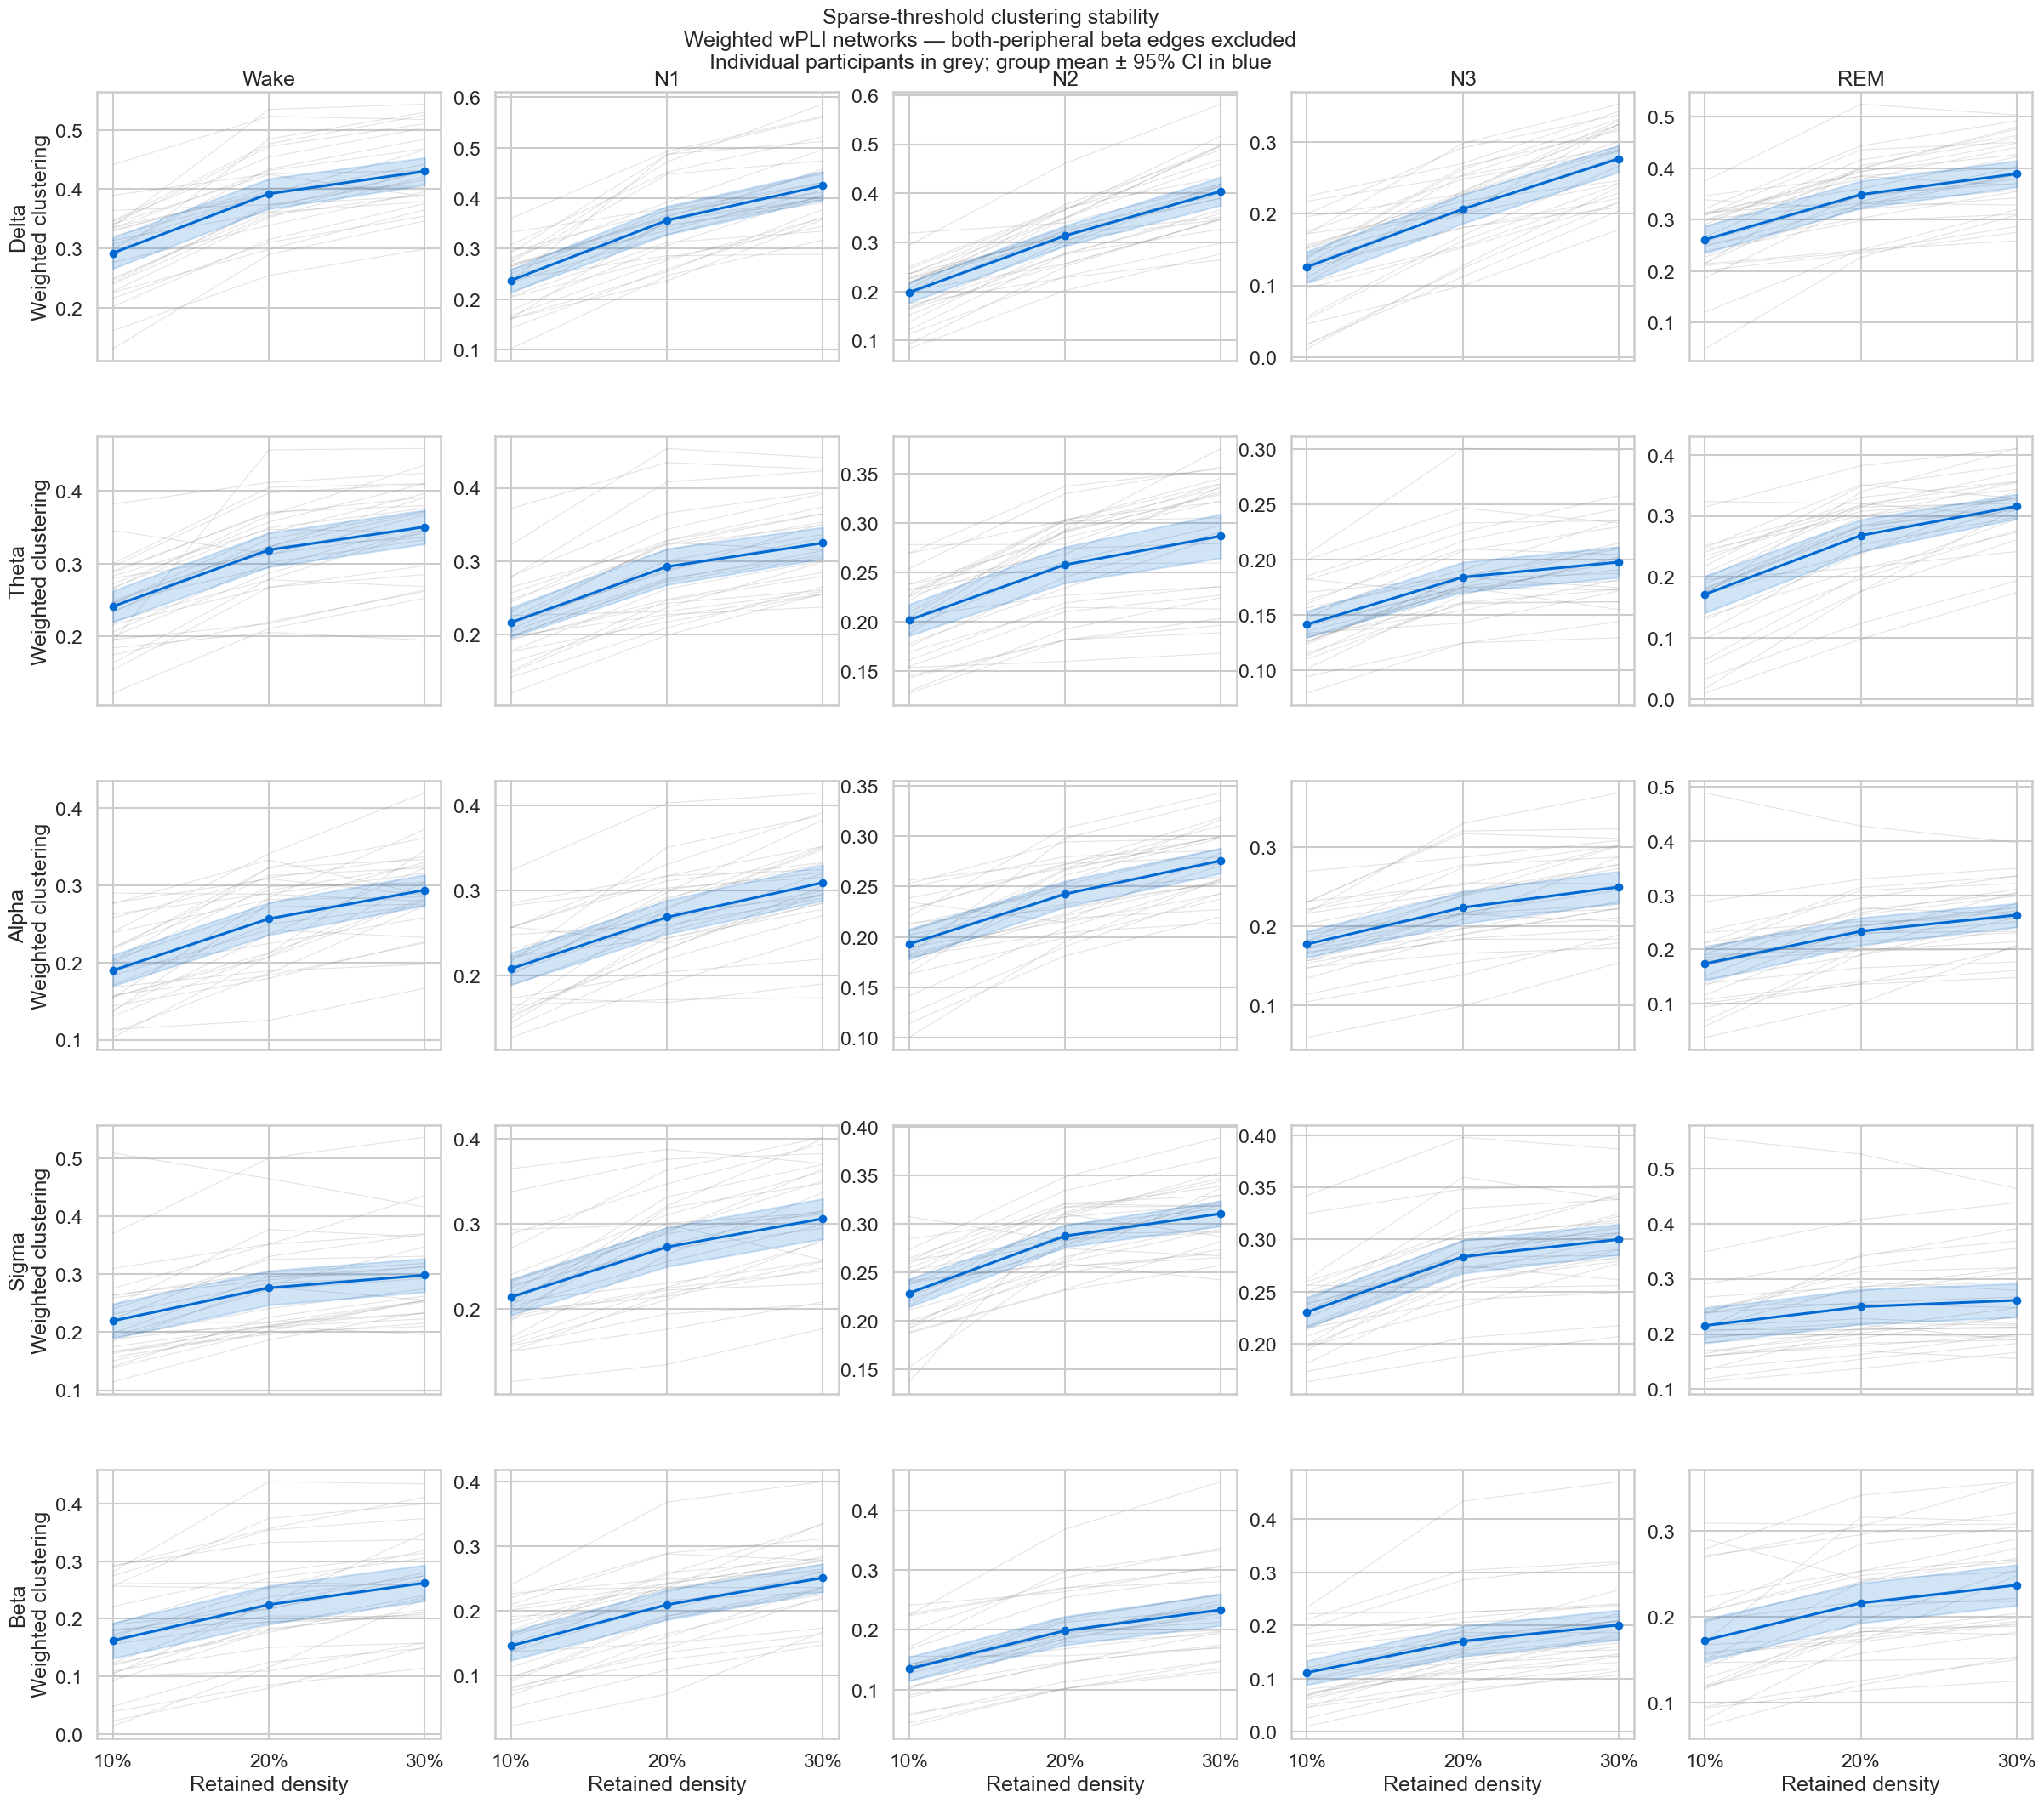

In [19]:
SPARSE_CLUSTERING_METRIC = "mean_weighted_clustering"

fig, axes = plt.subplots(
    nrows=len(BAND_ORDER),
    ncols=len(STAGE_ORDER),
    figsize=(25, 22),
    sharex=True,
    constrained_layout=False,
)

for band_index, band in enumerate(BAND_ORDER):
    for stage_index, stage in enumerate(STAGE_ORDER):

        ax = axes[band_index, stage_index]

        panel_data = sparse_stability_data.loc[
            (sparse_stability_data["band"] == band)
            & (sparse_stability_data["stage"] == stage)
        ].copy()

        if panel_data.empty:
            ax.set_visible(False)
            continue

        # Individual participant curves.
        for _, subject_data in panel_data.groupby("subject_id"):

            subject_data = (
                subject_data
                .set_index("requested_density")
                .reindex(SPARSE_DENSITIES)
                .reset_index()
            )

            ax.plot(
                subject_data["requested_density"] * 100,
                subject_data[SPARSE_CLUSTERING_METRIC],
                color="gray",
                alpha=0.22,
                linewidth=0.8,
                zorder=1,
            )

        # Group mean and standard error.
        summary = (
            panel_data
            .groupby("requested_density")[
                SPARSE_CLUSTERING_METRIC
            ]
            .agg(["mean", "std", "count"])
            .reindex(SPARSE_DENSITIES)
            .reset_index()
        )

        summary["sem"] = (
            summary["std"] / np.sqrt(summary["count"])
        )

        x_values = summary["requested_density"] * 100
        y_values = summary["mean"]
        lower_ci = y_values - 1.96 * summary["sem"]
        upper_ci = y_values + 1.96 * summary["sem"]

        ax.plot(
            x_values,
            y_values,
            color="#016ad2",
            marker="o",
            linewidth=2.2,
            markersize=6,
            zorder=3,
        )

        ax.fill_between(
            x_values,
            lower_ci,
            upper_ci,
            color="#016ad2",
            alpha=0.18,
            zorder=2,
        )

        ax.set_xticks([10, 20, 30])
        ax.set_xticklabels(["10%", "20%", "30%"])

        if band_index == 0:
            ax.set_title(stage)

        if stage_index == 0:
            ax.set_ylabel(
                f"{band.capitalize()}\n"
                "Weighted clustering"
            )

        if band_index == len(BAND_ORDER) - 1:
            ax.set_xlabel("Retained density")

fig.subplots_adjust(
    top=0.94,
    bottom=0.06,
    left=0.08,
    right=0.99,
    hspace=0.28,
    wspace=0.16,
)

fig.suptitle(
    "Sparse-threshold clustering stability\n"
    "Weighted wPLI networks — both-peripheral beta edges excluded\n"
    "Individual participants in grey; group mean ± 95% CI in blue",
    y=0.985,
    fontsize=18,
)

plt.show()

THESE ARE SUPLEMENTARY PLOTS (DENSITY SENSITIVITY, NOT TO SHOW STAIBILITY):

Examples that look fairly consistent:

- Delta: N3 remains the lowest-clustering stage across all three densities; Wake/N1 tend to remain higher.
- Theta: N3 remains relatively low, while Wake and REM tend to be higher.
- Beta: N3 is generally among the lower-clustering stages, with REM tending to be higher.
- Sigma: Stage differences are less consistent and more variable.
- Alpha: Stage ordering is comparatively subtle; no strong robust sparse-threshold conclusion stands out.

“Sparse-threshold clustering showed qualitatively similar stage ordering across the 10%–30% range, while low-density graphs were frequently fragmented; results are descriptive and interpreted alongside component quality control.”

In [20]:
sparse_component_qc.to_csv(
    THRESHOLD_OUTPUT_DIR / "sparse_threshold_component_qc.csv",
    index=False,
)

**Completed until now:**

Primary unthresholded analysis:
- Mean wPLI
- Weighted clustering
- Louvain modularity

Peripheral-beta control:
- Both-peripheral beta edges excluded
- Full beta retained as a sensitivity reference

Connected-threshold robustness:
- 85% and 90%
- All 700 graphs fully connected
- Global efficiency and path length computed
- Near-perfect 85%-vs-90% stability

Sparse-threshold sensitivity:
- 10%, 20%, 30%
- Clustering and modularity computed
- Component QC documented
- Fragmentation correctly identified and reported

**For the MST:**

- Mean MST edge weight
- Leaf fraction
- Tree hierarchy
- Diameter
- Weighted characteristic path length
- Degree-based measures, if useful

In [2]:
from pathlib import Path
import time

import h5py
import networkx as nx
import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

# Use the same excluded-beta stage-mean graphs used above.
STAGE_MEAN_DIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral"
)

MST_OUTPUT_DIR = Path(
    "../graphs_output/mst_metrics_exclude_both_beta_peripheral"
)
MST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------

def decode_value(x):
    return x.decode() if isinstance(x, bytes) else str(x)


def prepare_adjacency(A):
    """
    Prepare one symmetric non-negative wPLI adjacency matrix.

    For beta, the both-peripheral-edge correction has already been
    applied in the excluded-beta stage-mean HDF5 input files.
    """
    A = np.asarray(A, dtype=float).copy()
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    if np.any(A < 0):
        raise ValueError("Adjacency matrix contains negative weights.")

    return A


def maximum_spanning_tree_from_wpli(A):
    """
    Construct a maximum spanning tree using wPLI as edge strength.

    NetworkX's minimum_spanning_tree minimizes edge cost, so define:
        mst_cost = -wPLI

    Minimizing negative wPLI is equivalent to maximizing wPLI.

    The MST retains:
        n_nodes - 1 edges
    while connecting every node exactly once through the tree.
    """
    A = prepare_adjacency(A)

    n_nodes = A.shape[0]
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))

    iu, ju = np.triu_indices(n_nodes, k=1)

    for i, j in zip(iu, ju):
        weight = A[i, j]

        if weight > 0:
            G.add_edge(
                int(i),
                int(j),
                weight=float(weight),
                mst_cost=-float(weight),
            )

    if not nx.is_connected(G):
        raise RuntimeError(
            "The original weighted graph is disconnected before MST "
            "construction. Check the input stage-mean graph."
        )

    T = nx.minimum_spanning_tree(
        G,
        weight="mst_cost",
        algorithm="kruskal",
    )

    if not nx.is_tree(T):
        raise RuntimeError("MST construction failed: output is not a tree.")

    if T.number_of_nodes() != n_nodes:
        raise RuntimeError(
            "MST does not contain all original nodes."
        )

    if T.number_of_edges() != n_nodes - 1:
        raise RuntimeError(
            "MST does not contain n_nodes - 1 edges."
        )

    return T


def weighted_tree_path_length(T):
    """
    Calculate weighted characteristic path length in the MST.

    Each retained MST edge has:
        distance = 1 / wPLI

    All MSTs are connected by definition, so every pair has one path.
    """
    for _, _, data in T.edges(data=True):
        data["distance"] = 1.0 / data["weight"]

    distances = dict(
        nx.all_pairs_dijkstra_path_length(
            T,
            weight="distance",
        )
    )

    nodes = list(T.nodes())
    pair_distances = []

    for i, source in enumerate(nodes):
        for target in nodes[i + 1:]:
            pair_distances.append(
                distances[source][target]
            )

    return float(np.mean(pair_distances))


def compute_mst_metrics(T):
    """
    Calculate summary metrics for one maximum spanning tree.
    """
    n_nodes = T.number_of_nodes()
    n_edges = T.number_of_edges()

    edge_weights = np.array(
        [
            data["weight"]
            for _, _, data in T.edges(data=True)
        ],
        dtype=float,
    )

    degrees = np.array(
        [
            degree
            for _, degree in T.degree()
        ],
        dtype=float,
    )

    leaf_count = int(np.sum(degrees == 1))
    leaf_fraction = float(leaf_count / n_nodes)

    maximum_degree = int(np.max(degrees))
    mean_degree = float(np.mean(degrees))

    # Degree divergence: variability of node degree around mean degree.
    degree_divergence = float(np.std(degrees, ddof=0))

    # Tree hierarchy (Mijović et al.-style form):
    # H = leaf_count / [2 * (n_nodes - 2) * maximum_degree]
    #
    # Higher H reflects a tree with more leaves relative to its largest hub.
    # It should be interpreted comparatively across participants/stages/bands,
    # not as an absolute biological quantity.
    tree_hierarchy = float(leaf_count / (2.0 * (n_nodes - 2) * maximum_degree))

    # Topological diameter = longest number-of-edge path in the tree.
    topological_diameter = int(nx.diameter(T))

    # Weighted diameter = longest distance-based path.
    weighted_distances = dict(
        nx.all_pairs_dijkstra_path_length(
            T,
            weight="distance",
        )
    )
    weighted_diameter = float(
        max(
            distance
            for source_distances in weighted_distances.values()
            for distance in source_distances.values()
        )
    )

    weighted_path_length = weighted_tree_path_length(T)

    return {
        "n_nodes": n_nodes,
        "n_edges": n_edges,
        "n_connected_components": nx.number_connected_components(T),
        "is_tree": nx.is_tree(T),
        "mean_mst_edge_weight": float(np.mean(edge_weights)),
        "median_mst_edge_weight": float(np.median(edge_weights)),
        "minimum_mst_edge_weight": float(np.min(edge_weights)),
        "maximum_mst_edge_weight": float(np.max(edge_weights)),
        "leaf_count": leaf_count,
        "leaf_fraction": leaf_fraction,
        "maximum_degree": maximum_degree,
        "mean_degree": mean_degree,
        "degree_divergence": degree_divergence,
        "tree_hierarchy": tree_hierarchy,
        "topological_diameter": topological_diameter,
        "weighted_diameter": weighted_diameter,
        "weighted_characteristic_path_length": weighted_path_length,
    }


# ------------------------------------------------------------------
# Locate stage-mean excluded-beta graphs
# ------------------------------------------------------------------

stage_mean_paths = sorted(
    STAGE_MEAN_DIR.glob("*stage_means.h5")
)

if not stage_mean_paths:
    raise FileNotFoundError(
        f"No '*stage_means.h5' files found in:\n"
        f"{STAGE_MEAN_DIR.resolve()}"
    )

print(
    f"Found {len(stage_mean_paths)} excluded-beta "
    "stage-mean graph files."
)


# ------------------------------------------------------------------
# Compute MST metrics
# ------------------------------------------------------------------

mst_rows = []

start_time = time.perf_counter()
graphs_completed = 0

for subject_number, h5path in enumerate(stage_mean_paths, start=1):

    subject_start_time = time.perf_counter()

    with h5py.File(h5path, "r") as f:

        subject_id = decode_value(f.attrs["subject_id"])
        beta_edge_mode = decode_value(
            f.attrs["beta_edge_mode"]
        )

        if beta_edge_mode != "exclude_both_peripheral":
            raise ValueError(
                f"{h5path.name} has beta_edge_mode="
                f"{beta_edge_mode!r}. "
                "This MST analysis requires "
                "'exclude_both_peripheral'."
            )

        available_bands = [
            decode_value(x)
            for x in f.attrs["bands"]
        ]

        available_stages = [
            decode_value(x)
            for x in f.attrs["stages"]
        ]

        bands = [
            band for band in BAND_ORDER
            if band in available_bands
        ]

        stages = [
            stage for stage in STAGE_ORDER
            if stage in available_stages
        ]

        for band in bands:
            for stage in stages:

                if stage not in f[band]:
                    continue

                dataset = f[band][stage]
                A = np.asarray(dataset, dtype=float)

                if "n_epochs_averaged" in dataset.attrs:
                    n_epochs_averaged = int(
                        dataset.attrs["n_epochs_averaged"]
                    )
                else:
                    n_epochs_averaged = np.nan

                T = maximum_spanning_tree_from_wpli(A)
                metrics = compute_mst_metrics(T)

                mst_rows.append(
                    {
                        "subject_id": subject_id,
                        "band": band,
                        "stage": stage,
                        "beta_edge_mode": beta_edge_mode,
                        "n_epochs_averaged": n_epochs_averaged,
                        **metrics,
                    }
                )

                graphs_completed += 1

    elapsed_subject = (
        time.perf_counter() - subject_start_time
    )

    print(
        f"{subject_number:02d}/{len(stage_mean_paths)} "
        f"{subject_id} complete "
        f"({graphs_completed} graphs total; "
        f"{elapsed_subject:.1f} s)"
    )


# ------------------------------------------------------------------
# Create, validate, and save output
# ------------------------------------------------------------------

mst_metrics = pd.DataFrame(mst_rows)

expected_graphs = (
    len(stage_mean_paths)
    * len(BAND_ORDER)
    * len(STAGE_ORDER)
)

assert len(mst_metrics) == expected_graphs, (
    f"Expected {expected_graphs} graph rows, "
    f"but obtained {len(mst_metrics)}."
)

assert (mst_metrics["n_nodes"] == 83).all()
assert (mst_metrics["n_edges"] == 82).all()
assert (mst_metrics["n_connected_components"] == 1).all()
assert mst_metrics["is_tree"].all()

mst_output_path = MST_OUTPUT_DIR / (
    "mst_static_metrics_exclude_both_peripheral_beta.csv"
)

mst_metrics.to_csv(
    mst_output_path,
    index=False,
)


# ------------------------------------------------------------------
# Output summary
# ------------------------------------------------------------------

elapsed_minutes = (
    time.perf_counter() - start_time
) / 60

print("\n" + "=" * 70)
print("MST ANALYSIS COMPLETE")
print("=" * 70)
print(f"Graphs processed: {len(mst_metrics)}")
print(f"Expected graphs: {expected_graphs}")
print(f"Elapsed time: {elapsed_minutes:.2f} minutes")
print(f"Saved to: {mst_output_path}")

print("\nMST structural QC:")

mst_qc = pd.DataFrame(
    {
        "n_graphs": [len(mst_metrics)],
        "minimum_nodes": [mst_metrics["n_nodes"].min()],
        "maximum_nodes": [mst_metrics["n_nodes"].max()],
        "minimum_edges": [mst_metrics["n_edges"].min()],
        "maximum_edges": [mst_metrics["n_edges"].max()],
        "minimum_components": [
            mst_metrics["n_connected_components"].min()
        ],
        "maximum_components": [
            mst_metrics["n_connected_components"].max()
        ],
        "all_graphs_are_trees": [
            mst_metrics["is_tree"].all()
        ],
    }
)

display(mst_qc)

print("\nMST metric preview:")
display(mst_metrics.head())

Found 28 excluded-beta stage-mean graph files.
01/28 EPCTL01 complete (25 graphs total; 1.8 s)
02/28 EPCTL02 complete (50 graphs total; 1.8 s)
03/28 EPCTL03 complete (75 graphs total; 2.5 s)
04/28 EPCTL04 complete (100 graphs total; 4.0 s)
05/28 EPCTL05 complete (125 graphs total; 4.1 s)
06/28 EPCTL06 complete (150 graphs total; 3.8 s)
07/28 EPCTL07 complete (175 graphs total; 4.1 s)
08/28 EPCTL09 complete (200 graphs total; 4.0 s)
09/28 EPCTL10 complete (225 graphs total; 4.2 s)
10/28 EPCTL11 complete (250 graphs total; 3.9 s)
11/28 EPCTL12 complete (275 graphs total; 4.2 s)
12/28 EPCTL13 complete (300 graphs total; 4.2 s)
13/28 EPCTL14 complete (325 graphs total; 4.2 s)
14/28 EPCTL15 complete (350 graphs total; 3.8 s)
15/28 EPCTL16 complete (375 graphs total; 3.9 s)
16/28 EPCTL17 complete (400 graphs total; 4.3 s)
17/28 EPCTL18 complete (425 graphs total; 3.8 s)
18/28 EPCTL19 complete (450 graphs total; 4.3 s)
19/28 EPCTL20 complete (475 graphs total; 4.0 s)
20/28 EPCTL21 complete (5

,n_graphs,minimum_nodes,maximum_nodes,minimum_edges,maximum_edges,minimum_components,maximum_components,all_graphs_are_trees
0,700,83,83,82,82,1,1,True



MST metric preview:


,subject_id,band,stage,beta_edge_mode,n_epochs_averaged,n_nodes,n_edges,n_connected_components,is_tree,mean_mst_edge_weight,...,maximum_mst_edge_weight,leaf_count,leaf_fraction,maximum_degree,mean_degree,degree_divergence,tree_hierarchy,topological_diameter,weighted_diameter,weighted_characteristic_path_length
0,EPCTL01,delta,Wake,exclude_both_peripheral,46,83,82,1,True,0.361806,...,0.441151,55,0.662651,17,1.975904,2.414693,0.019971,13,13.0,14.213458
1,EPCTL01,delta,N1,exclude_both_peripheral,74,83,82,1,True,0.287298,...,0.364185,57,0.686747,14,1.975904,2.216998,0.025132,12,12.0,19.796816
2,EPCTL01,delta,N2,exclude_both_peripheral,471,83,82,1,True,0.302803,...,0.387984,57,0.686747,17,1.975904,2.297069,0.020697,11,11.0,16.359352
3,EPCTL01,delta,N3,exclude_both_peripheral,185,83,82,1,True,0.302401,...,0.366949,55,0.662651,21,1.975904,2.483565,0.016167,11,11.0,16.938550
4,EPCTL01,delta,REM,exclude_both_peripheral,176,83,82,1,True,0.229713,...,0.319784,56,0.674699,22,1.975904,2.997894,0.015713,13,13.0,23.145150


Beta-edge mode plotted:
<StringArray>
['exclude_both_peripheral']
Length: 1, dtype: str

Graphs by frequency band and sleep stage:


,band,stage,n_graphs
0,alpha,N1,28
1,alpha,N2,28
2,alpha,N3,28
3,alpha,REM,28
4,alpha,Wake,28
5,beta,N1,28
6,beta,N2,28
7,beta,N3,28
8,beta,REM,28
9,beta,Wake,28


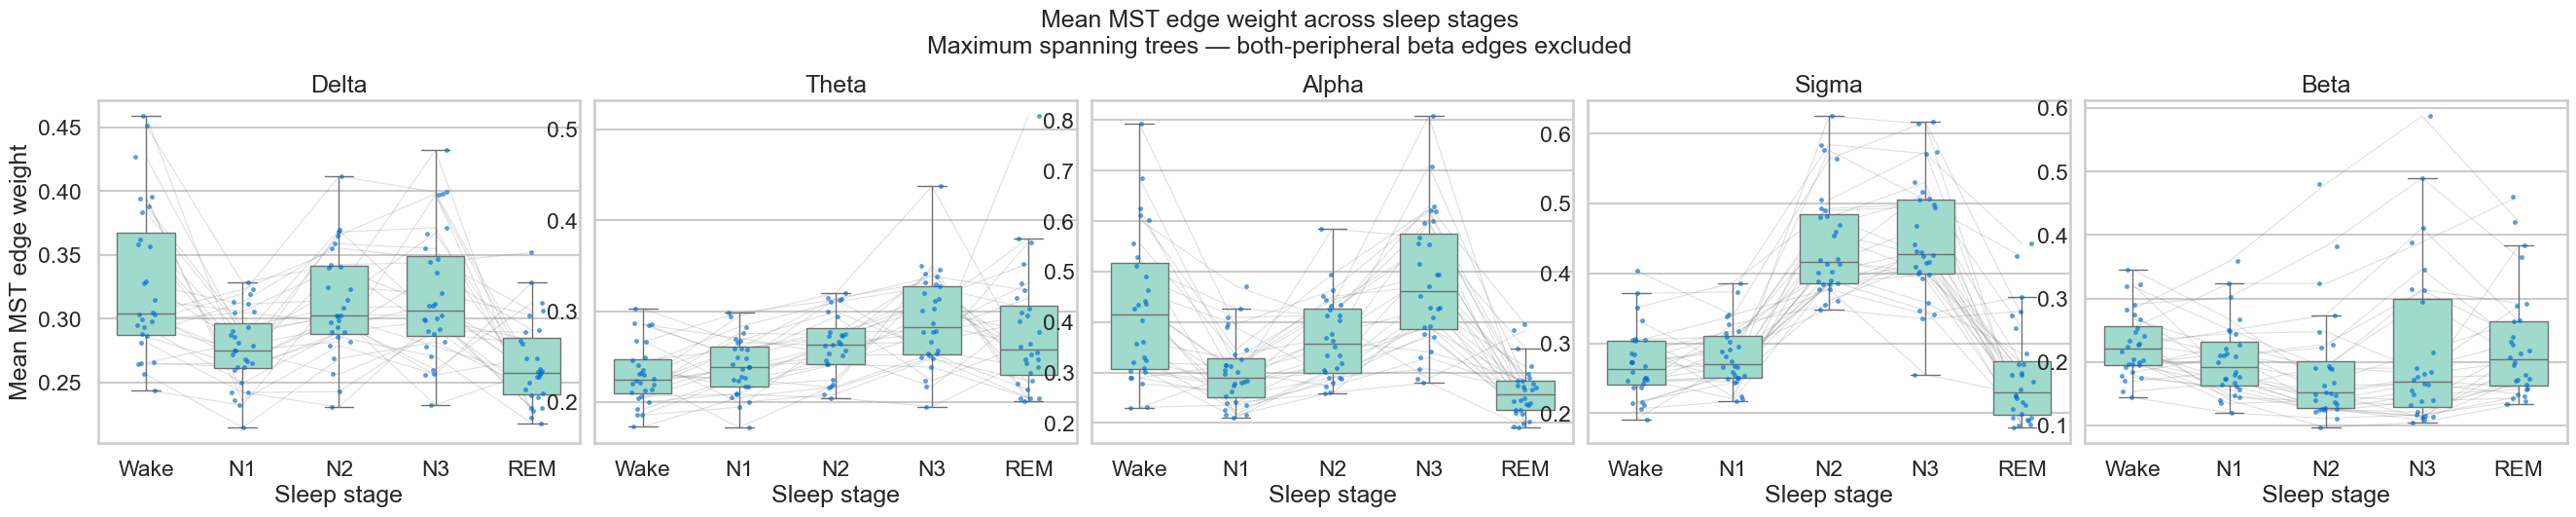

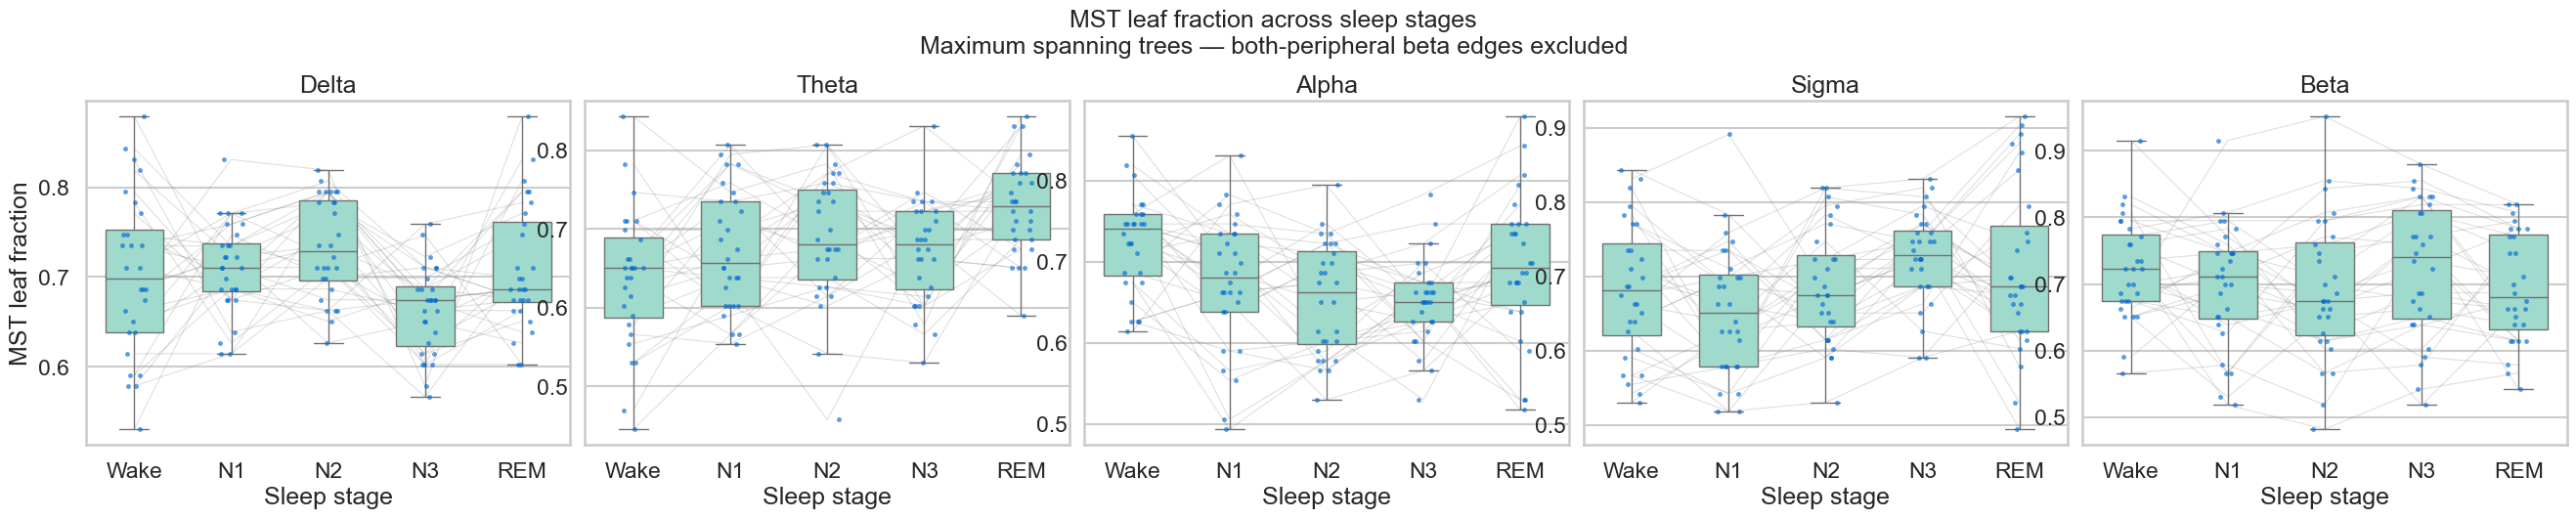

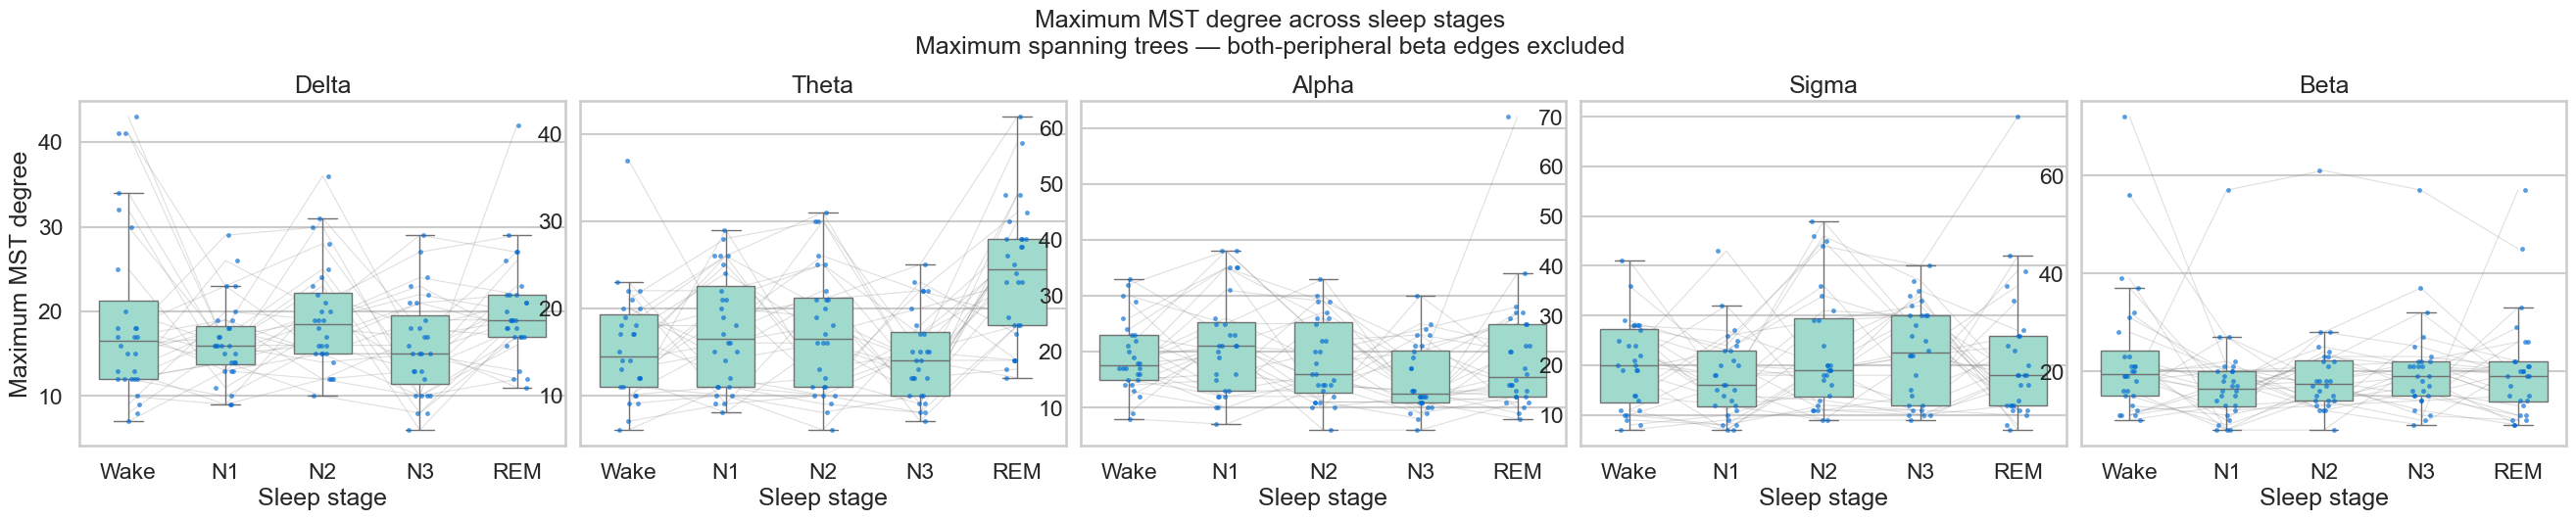

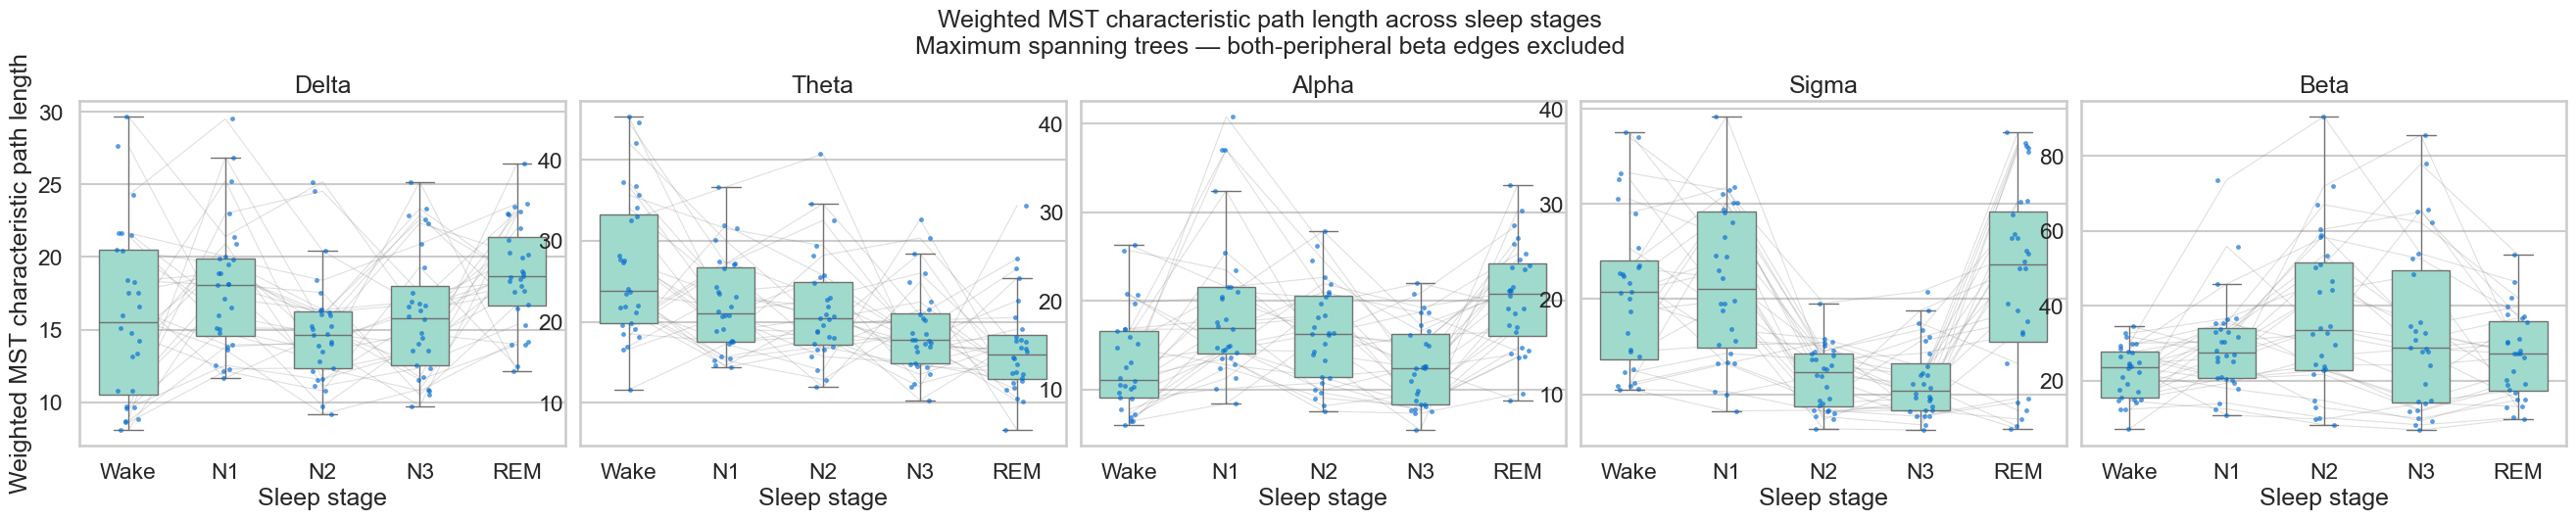

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

sns.set_theme(style="whitegrid", context="talk")

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]


# ------------------------------------------------------------------
# Prepare MST table
# ------------------------------------------------------------------

mst_plot_data = mst_metrics.copy()

# Basic safety checks before plotting.
assert len(mst_plot_data) == 700

assert (mst_plot_data["n_nodes"] == 83).all()
assert (mst_plot_data["n_edges"] == 82).all()
assert (mst_plot_data["n_connected_components"] == 1).all()
assert mst_plot_data["is_tree"].all()

print("Beta-edge mode plotted:")
print(mst_plot_data["beta_edge_mode"].unique())

print("\nGraphs by frequency band and sleep stage:")
display(
    mst_plot_data
    .groupby(["band", "stage"])
    .size()
    .rename("n_graphs")
    .reset_index()
)


# ------------------------------------------------------------------
# Select primary MST metrics
# ------------------------------------------------------------------

MST_PRIMARY_METRICS = {
    "mean_mst_edge_weight": "Mean MST edge weight",
    "leaf_fraction": "MST leaf fraction",
    "maximum_degree": "Maximum MST degree",
    "weighted_characteristic_path_length":
        "Weighted MST characteristic path length",
}


# ------------------------------------------------------------------
# Plot one figure per metric
# Rows are not required because MST has one topology per graph.
# Columns correspond to frequency bands.
# ------------------------------------------------------------------

for metric_name, metric_label in MST_PRIMARY_METRICS.items():

    fig, axes = plt.subplots(
        1,
        len(BAND_ORDER),
        figsize=(27, 5.5),
        sharey=False,
        constrained_layout=False,
    )

    for ax, band in zip(axes, BAND_ORDER):

        band_data = mst_plot_data.loc[
            mst_plot_data["band"] == band
        ].copy()

        if band_data.empty:
            ax.set_visible(False)
            continue

        # One grey within-participant trajectory across stages.
        for _, subject_data in band_data.groupby("subject_id"):

            subject_values = (
                subject_data
                .set_index("stage")[metric_name]
                .reindex(STAGE_ORDER)
            )

            ax.plot(
                np.arange(len(STAGE_ORDER)),
                subject_values,
                color="gray",
                alpha=0.25,
                linewidth=0.8,
                zorder=1,
            )

        # Group-level distribution across the 28 participants.
        sns.boxplot(
            data=band_data,
            x="stage",
            y=metric_name,
            order=STAGE_ORDER,
            ax=ax,
            color="#95e4d2",
            width=0.60,
            showfliers=False,
            zorder=2,
        )

        # Individual participant values.
        sns.stripplot(
            data=band_data,
            x="stage",
            y=metric_name,
            order=STAGE_ORDER,
            ax=ax,
            color="#016ad2",
            alpha=0.65,
            size=3.5,
            jitter=0.12,
            zorder=3,
        )

        ax.set_title(band.capitalize())
        ax.set_xlabel("Sleep stage")

        if band == BAND_ORDER[0]:
            ax.set_ylabel(metric_label)
        else:
            ax.set_ylabel("")

    fig.subplots_adjust(
        top=0.80,
        bottom=0.16,
        left=0.05,
        right=0.99,
        wspace=0.03,
    )

    fig.suptitle(
        f"{metric_label} across sleep stages\n"
        "Maximum spanning trees — "
        "both-peripheral beta edges excluded",
        y=0.97,
        fontsize=18,
    )

    plt.show()

An MST keeps only 82 edges for 83 nodes, selecting the strongest set of connections needed to maintain one connected network. So it answers: “How does the strongest connected connectivity backbone change across sleep stages?”

**MAIN MST PATTERNS:**

**Mean MST edge weight**

Higher values mean stronger backbone wPLI connections.

| Band  | Broad pattern visible in plot                                 |
| ----- | ------------------------------------------------------------- |
| Delta | Higher in Wake/N2/N3; clearly lower in REM                    |
| Theta | Increases toward N3, then decreases in REM                    |
| Alpha | Higher in Wake/N3; lower in N1 and especially REM             |
| Sigma | Markedly higher in N2/N3; lowest in REM                       |
| Beta  | Lowest around N2; somewhat higher in Wake/N3/REM but variable |

The clearest finding is again sigma. N2/N3: Strongest MST backbone edges. REM: Weakest MST backbone edges.

**Weighted MST path length**

Higher weighted path length means less efficient communication through the strongest connected backbone.

| Band  | Broad pattern visible in plot              |
| ----- | ------------------------------------------ |
| Delta | N2 is shortest; REM is longest             |
| Theta | Progressively shorter from Wake toward REM |
| Alpha | Shortest in Wake/N3; longest in REM        |
| Sigma | Shortest in N2/N3; longest in REM          |
| Beta  | Longest around N2/N3; lower in Wake/REM    |

That provides a sparse-backbone version of the same general stage pattern observed in the connected 85%/90% networks.

**TREE TOPLOGY MEASURES**

**Leaf fraction:**

It is the proportion of nodes with only one MST connection. Higher leaf fraction: more terminal/peripheral nodes. Lower leaf fraction: fewer terminal nodes and more distributed branching.

Visible patterns include:

- Delta: Lower leaf fraction in N3, with higher values in N2 and REM.
- Theta: Leaf fraction generally rises toward REM.
- Alpha: Leaf fraction falls from Wake toward N3, then rises in REM.
- Sigma: Lowest around N1, higher in N3/REM.
- Beta: Variable, with a tendency toward higher values in N3.

These are valid tree-structure differences, but leaf fraction should be interpreted together with maximum degree:

**Maximum degree:**

It indicates the number of connections attached to the tree’s largest hub. Higher maximum degree: a more dominant single hub. Lower maximum degree: less hub-dominated backbone organization.

Broadly:

- Delta: Maximum degree is lower in N1/N3 and higher in Wake/N2/REM.
- Theta: Maximum degree rises strongly in REM.
- Alpha: Maximum degree drops in N3; Wake/N1/N2 are higher.
- Sigma: Maximum degree tends to rise in N2/N3.
- Beta: Differences are smaller, although Wake includes some highly hub-dominated individuals.

Maximum spanning tree analysis provided a sparse, fully connected robustness check. Broad stage-related patterns in backbone strength and weighted path length were consistent with the connected proportional-threshold analysis, particularly the relatively integrated sigma backbone during N2/N3 and reduced backbone integration during REM. Other bands showed stage-dependent changes, but their magnitude and consistency varied across participants.

In interpretive terms, a stronger MST backbone edge weight indicates that the high-confidence connections needed to link the network are stronger. A shorter weighted MST path length indicates that the strongest connectivity backbone provides more efficient routes between sensors, whereas a longer path length indicates weaker and/or less efficiently arranged backbone connections. Therefore, the sigma pattern suggests that during N2/N3 the strongest sigma-band connections form a relatively efficient backbone, while REM is characterized by a weaker and less efficient sigma backbone. This should be interpreted as a sensor-level functional-connectivity pattern, rather than direct evidence of anatomical pathways, information flow, or causal neural communication.

In [5]:
#Calculation of the normalized-Laplacian spectral entropy for the unthresholded excluded-beta 
#stage-mean weighted wPLI graphs:

from pathlib import Path
import time

import h5py
import numpy as np
import pandas as pd


# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------

# Use the primary unthresholded excluded-beta stage-mean graphs.
STAGE_MEAN_DIR = Path(
    "../graphs_output/stage_mean_wpli_graphs_exclude_both_beta_peripheral"
)

ENTROPY_OUTPUT_DIR = Path(
    "../graphs_output/graph_entropy_exclude_both_beta_peripheral"
)
ENTROPY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_ORDER = ["Wake", "N1", "N2", "N3", "REM"]
BAND_ORDER = ["delta", "theta", "alpha", "sigma", "beta"]

EPSILON = 1e-12


# ------------------------------------------------------------------
# Helpers
# ------------------------------------------------------------------

def decode_value(x):
    return x.decode() if isinstance(x, bytes) else str(x)


def prepare_adjacency(A):
    """
    Prepare a weighted undirected wPLI adjacency matrix.

    The input files already contain the selected beta correction:
    both-peripheral beta edges are zero, while all 83 nodes remain.
    """
    A = np.asarray(A, dtype=float).copy()

    # Ensure exact symmetry and remove self-connections.
    A = (A + A.T) / 2.0
    np.fill_diagonal(A, 0.0)

    if np.any(A < 0):
        raise ValueError("Adjacency matrix contains negative weights.")

    if not np.all(np.isfinite(A)):
        raise ValueError(
            "Adjacency matrix contains NaN or infinite values."
        )

    return A


def normalized_laplacian_spectral_entropy(A):
    """
    Calculate normalized-Laplacian spectral entropy.

    Steps:
        1. Calculate weighted node strengths:
               d_i = sum_j W_ij

        2. Construct the symmetric normalized Laplacian:
               L_norm = I - D^(-1/2) W D^(-1/2)

        3. Obtain its real eigenvalues.

        4. Normalize eigenvalues to probabilities:
               p_i = lambda_i / sum(lambda)

        5. Compute Shannon entropy and divide by log(n):
               H_norm = -sum(p_i * log(p_i)) / log(n)

    Returns:
        entropy_normalized:
            Spectral entropy approximately in [0, 1].

        entropy_raw:
            Shannon entropy before division by log(n).

        lambda_sum:
            Sum of normalized-Laplacian eigenvalues.

        n_zero_eigenvalues:
            Number of near-zero eigenvalues. For a connected graph,
            this should be 1.

        algebraic_connectivity:
            Second-smallest normalized-Laplacian eigenvalue.
            Larger values generally indicate stronger connectivity.
    """
    W = prepare_adjacency(A)
    n_nodes = W.shape[0]

    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError("Adjacency matrix must be square.")

    strengths = W.sum(axis=1)

    if np.any(strengths <= EPSILON):
        bad_nodes = np.flatnonzero(strengths <= EPSILON)

        raise ValueError(
            f"Graph has isolated or near-isolated nodes: "
            f"{bad_nodes.tolist()}"
        )

    inv_sqrt_strengths = 1.0 / np.sqrt(strengths)

    normalized_adjacency = (
        inv_sqrt_strengths[:, None]
        * W
        * inv_sqrt_strengths[None, :]
    )

    L_norm = np.eye(n_nodes) - normalized_adjacency

    # Numerical symmetry safeguard before eigendecomposition.
    L_norm = (L_norm + L_norm.T) / 2.0

    eigenvalues = np.linalg.eigvalsh(L_norm)

    # Remove tiny numerical negative values close to zero.
    eigenvalues = np.clip(eigenvalues, 0.0, None)

    lambda_sum = float(eigenvalues.sum())

    if lambda_sum <= EPSILON:
        raise ValueError(
            "Normalized-Laplacian eigenvalue sum is zero."
        )

    probabilities = eigenvalues / lambda_sum

    valid_probabilities = probabilities[
        probabilities > EPSILON
    ]

    entropy_raw = float(
        -np.sum(
            valid_probabilities
            * np.log(valid_probabilities)
        )
    )

    entropy_normalized = float(
        entropy_raw / np.log(n_nodes)
    )

    n_zero_eigenvalues = int(
        np.sum(eigenvalues <= 1e-8)
    )

    algebraic_connectivity = float(
        eigenvalues[1]
    ) if n_nodes > 1 else np.nan

    return {
        "normalized_laplacian_spectral_entropy":
            entropy_normalized,
        "laplacian_spectral_entropy_raw":
            entropy_raw,
        "laplacian_eigenvalue_sum":
            lambda_sum,
        "n_zero_laplacian_eigenvalues":
            n_zero_eigenvalues,
        "algebraic_connectivity":
            algebraic_connectivity,
        "minimum_laplacian_eigenvalue":
            float(eigenvalues.min()),
        "maximum_laplacian_eigenvalue":
            float(eigenvalues.max()),
        "mean_node_strength_for_entropy":
            float(strengths.mean()),
    }


# ------------------------------------------------------------------
# Locate excluded-beta stage-mean HDF5 graphs
# ------------------------------------------------------------------

stage_mean_paths = sorted(
    STAGE_MEAN_DIR.glob("*stage_means.h5")
)

if not stage_mean_paths:
    raise FileNotFoundError(
        f"No '*stage_means.h5' files found in:\n"
        f"{STAGE_MEAN_DIR.resolve()}"
    )

print(
    f"Found {len(stage_mean_paths)} excluded-beta "
    "stage-mean graph files."
)


# ------------------------------------------------------------------
# Calculate entropy for every participant × band × stage graph
# ------------------------------------------------------------------

entropy_rows = []

start_time = time.perf_counter()
graphs_completed = 0

for subject_number, h5path in enumerate(stage_mean_paths, start=1):

    subject_start_time = time.perf_counter()

    with h5py.File(h5path, "r") as f:

        subject_id = decode_value(
            f.attrs["subject_id"]
        )

        beta_edge_mode = decode_value(
            f.attrs["beta_edge_mode"]
        )

        if beta_edge_mode != "exclude_both_peripheral":
            raise ValueError(
                f"{h5path.name} has beta_edge_mode="
                f"{beta_edge_mode!r}. "
                "This entropy analysis requires "
                "'exclude_both_peripheral'."
            )

        available_bands = [
            decode_value(x)
            for x in f.attrs["bands"]
        ]

        available_stages = [
            decode_value(x)
            for x in f.attrs["stages"]
        ]

        bands = [
            band for band in BAND_ORDER
            if band in available_bands
        ]

        stages = [
            stage for stage in STAGE_ORDER
            if stage in available_stages
        ]

        for band in bands:
            for stage in stages:

                if stage not in f[band]:
                    continue

                dataset = f[band][stage]

                A = np.asarray(
                    dataset,
                    dtype=float,
                )

                if "n_epochs_averaged" in dataset.attrs:
                    n_epochs_averaged = int(
                        dataset.attrs[
                            "n_epochs_averaged"
                        ]
                    )
                else:
                    n_epochs_averaged = np.nan

                entropy_metrics = (
                    normalized_laplacian_spectral_entropy(A)
                )

                entropy_rows.append(
                    {
                        "subject_id": subject_id,
                        "band": band,
                        "stage": stage,
                        "beta_edge_mode": beta_edge_mode,
                        "n_epochs_averaged": n_epochs_averaged,
                        "n_nodes": A.shape[0],
                        **entropy_metrics,
                    }
                )

                graphs_completed += 1

    elapsed_subject = (
        time.perf_counter() - subject_start_time
    )

    print(
        f"{subject_number:02d}/{len(stage_mean_paths)} "
        f"{subject_id} complete "
        f"({graphs_completed} graphs total; "
        f"{elapsed_subject:.2f} s)"
    )


# ------------------------------------------------------------------
# Create and validate entropy table
# ------------------------------------------------------------------

entropy_metrics = pd.DataFrame(entropy_rows)

expected_graphs = (
    len(stage_mean_paths)
    * len(BAND_ORDER)
    * len(STAGE_ORDER)
)

assert len(entropy_metrics) == expected_graphs, (
    f"Expected {expected_graphs} graphs, "
    f"but obtained {len(entropy_metrics)}."
)

assert (entropy_metrics["n_nodes"] == 83).all()

assert (
    entropy_metrics[
        "normalized_laplacian_spectral_entropy"
    ].between(0.0, 1.0)
).all(), (
    "At least one normalized entropy value is outside [0, 1]."
)

# All unthresholded stage-mean graphs should be connected.
# A connected graph has exactly one near-zero Laplacian eigenvalue.
assert (
    entropy_metrics[
        "n_zero_laplacian_eigenvalues"
    ] == 1
).all(), (
    "Unexpected number of zero Laplacian eigenvalues. "
    "Check graph connectivity or numerical tolerance."
)

assert (
    entropy_metrics["algebraic_connectivity"] > 0
).all(), (
    "At least one graph has non-positive algebraic connectivity."
)


# ------------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------------

entropy_output_path = ENTROPY_OUTPUT_DIR / (
    "normalized_laplacian_spectral_entropy_"
    "exclude_both_peripheral_beta.csv"
)

entropy_metrics.to_csv(
    entropy_output_path,
    index=False,
)


# ------------------------------------------------------------------
# Report results
# ------------------------------------------------------------------

elapsed_minutes = (
    time.perf_counter() - start_time
) / 60

print("\n" + "=" * 70)
print("NORMALIZED LAPLACIAN SPECTRAL ENTROPY COMPLETE")
print("=" * 70)

print(f"Graphs processed: {len(entropy_metrics)}")
print(f"Expected graphs: {expected_graphs}")
print(f"Elapsed time: {elapsed_minutes:.3f} minutes")
print(f"Saved to: {entropy_output_path}")

print("\nEntropy range:")
display(
    entropy_metrics[
        [
            "normalized_laplacian_spectral_entropy",
            "laplacian_spectral_entropy_raw",
            "algebraic_connectivity",
            "mean_node_strength_for_entropy",
        ]
    ]
    .describe()
    .T
)

print("\nQC summary:")
display(
    pd.DataFrame(
        {
            "n_graphs": [len(entropy_metrics)],
            "nodes_per_graph": [
                entropy_metrics["n_nodes"].unique().tolist()
            ],
            "zero_eigenvalues_per_graph": [
                entropy_metrics[
                    "n_zero_laplacian_eigenvalues"
                ].unique().tolist()
            ],
            "all_entropy_values_in_0_to_1": [
                entropy_metrics[
                    "normalized_laplacian_spectral_entropy"
                ].between(0.0, 1.0)
                .all()
            ],
            "all_algebraic_connectivity_positive": [
                (
                    entropy_metrics[
                        "algebraic_connectivity"
                    ] > 0
                ).all()
            ],
        }
    )
)

print("\nEntropy-table preview:")
display(entropy_metrics.head())

Found 28 excluded-beta stage-mean graph files.
01/28 EPCTL01 complete (25 graphs total; 0.21 s)
02/28 EPCTL02 complete (50 graphs total; 0.09 s)
03/28 EPCTL03 complete (75 graphs total; 0.09 s)
04/28 EPCTL04 complete (100 graphs total; 0.07 s)
05/28 EPCTL05 complete (125 graphs total; 0.07 s)
06/28 EPCTL06 complete (150 graphs total; 0.08 s)
07/28 EPCTL07 complete (175 graphs total; 0.07 s)
08/28 EPCTL09 complete (200 graphs total; 0.07 s)
09/28 EPCTL10 complete (225 graphs total; 0.08 s)
10/28 EPCTL11 complete (250 graphs total; 0.08 s)
11/28 EPCTL12 complete (275 graphs total; 0.09 s)
12/28 EPCTL13 complete (300 graphs total; 0.09 s)
13/28 EPCTL14 complete (325 graphs total; 0.08 s)
14/28 EPCTL15 complete (350 graphs total; 0.10 s)
15/28 EPCTL16 complete (375 graphs total; 0.07 s)
16/28 EPCTL17 complete (400 graphs total; 0.07 s)
17/28 EPCTL18 complete (425 graphs total; 0.07 s)
18/28 EPCTL19 complete (450 graphs total; 0.08 s)
19/28 EPCTL20 complete (475 graphs total; 0.07 s)
20/28 

,count,mean,std,min,25%,50%,75%,max
normalized_laplacian_spectral_entropy,700.0,0.997190,0.000065,0.996909,0.997153,0.997216,0.997237,0.997254
laplacian_spectral_entropy_raw,700.0,4.406424,0.000286,4.405184,4.406261,4.406540,4.406630,4.406706
algebraic_connectivity,700.0,0.930146,0.037847,0.799404,0.907447,0.937469,0.957711,0.996637
mean_node_strength_for_entropy,700.0,15.543768,5.237919,5.483523,12.569700,14.980109,18.702119,50.504926



QC summary:


,n_graphs,nodes_per_graph,zero_eigenvalues_per_graph,all_entropy_values_in_0_to_1,all_algebraic_connectivity_positive
0,700,[83],[1],True,True



Entropy-table preview:


,subject_id,band,stage,beta_edge_mode,n_epochs_averaged,n_nodes,normalized_laplacian_spectral_entropy,laplacian_spectral_entropy_raw,laplacian_eigenvalue_sum,n_zero_laplacian_eigenvalues,algebraic_connectivity,minimum_laplacian_eigenvalue,maximum_laplacian_eigenvalue,mean_node_strength_for_entropy
0,EPCTL01,delta,Wake,exclude_both_peripheral,46,83,0.997243,4.406657,83.0,1,0.963250,4.440892e-16,1.052515,23.148764
1,EPCTL01,delta,N1,exclude_both_peripheral,74,83,0.997243,4.406658,83.0,1,0.981393,0.000000e+00,1.078515,18.361749
2,EPCTL01,delta,N2,exclude_both_peripheral,471,83,0.997246,4.406673,83.0,1,0.980088,0.000000e+00,1.069276,20.283053
3,EPCTL01,delta,N3,exclude_both_peripheral,185,83,0.997243,4.406659,83.0,1,0.970393,2.220446e-16,1.061556,18.705349
4,EPCTL01,delta,REM,exclude_both_peripheral,176,83,0.997249,4.406685,83.0,1,0.974463,0.000000e+00,1.039627,15.070567


The  graphs are dense. Their normalized spectral distributions are similar. This particular normalization removes much of the variation that might otherwise distinguish stages or bands. For the unthresholded, very dense stage-mean wPLI graphs, this particular normalized-Laplacian entropy is almost saturated and is unlikely to be very informative as a primary outcome Nevertheless:

The entropy computation already done is valuable: it demonstrated that normalized-Laplacian spectral entropy is near-saturated for the unthresholded stage-mean representation. That is enough justification **to reserve entropy for epoch-level or window-level graphs**, where there may be more meaningful temporal variation. The normalized Laplacian can itself be scaled to a graph density matrix, and graph entropy based on it is sensitive to the spectrum induced by graph representation and density.

BEFORE GNN:

*Classical graph-theoretical analysis was conducted on participant-specific stage-mean wPLI networks to characterize stable frequency-specific differences in network strength, segregation, community structure, and integration. Threshold and maximum-spanning-tree analyses were used as robustness checks. Temporal network dynamics, including graph-complexity and entropy measures, were reserved for epoch-level graph sequences and graph neural network modelling, enabling assessment of within-stage variability and changes across sleep-stage transitions.*